In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
import matplotlib as mpl
import lightkurve as lk
import matplotlib.patches as patches
from matplotlib.patches import Circle

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

# --- Edit these paths as needed ---

DATA_FILE = '../../final_model/parallel_fixed/e110/umap/umap_age_best_model_multiscale_data.npz'
PHOT_CSV  = '../../data/all_combined_metadata.csv'

data      = np.load(DATA_FILE, allow_pickle=True)
embedding = data['embedding']    # (N, 2)
ages      = data['ages']         # (N,) Myr
bprp0     = data['bprp0']        # (N,)
gaia_ids  = data['gaia_ids']     # (N,) str
tic_ids   = data['tic_ids']      # (N,) int64
sectors = data['sectors']        # (N,) int64

print(f'Loaded {len(ages)} samples')
print(f'Embedding shape: {embedding.shape}')
print(f'Age range:   {np.nanmin(ages):.1f} – {np.nanmax(ages):.1f} Myr')
print(f'BPRP0 range: {np.nanmin(bprp0):.2f} – {np.nanmax(bprp0):.2f}')

Loaded 60631 samples
Embedding shape: (60631, 2)
Age range:   1.5 – 8820.0 Myr
BPRP0 range: -0.48 – 5.24


## UMAP Latent Space Analysis

Load pre-computed UMAP embeddings and replot with different metadata coloring.

The `.npz` file contains:
- `embedding`: (N, 2) UMAP coordinates
- `ages`: (N,) ages in Myr
- `bprp0`: (N,) Gaia BP-RP color
- `latent_vectors`: (N, D) raw latent features
- `gaia_ids`: (N,) GaiaDR3_ID strings
- `tic_ids`: (N,) TESS TIC IDs (int64)

To join additional metadata, use `gaia_ids` to merge against `data/phot_all.csv`.

In [230]:
# Join additional metadata from phot_all.csv via GaiaDR3_ID
phot = pd.read_csv(PHOT_CSV, dtype={'GaiaDR3_ID': str})

df = pd.DataFrame({'GaiaDR3_ID': gaia_ids, 'tic': tic_ids})
df = df.merge(phot, on='GaiaDR3_ID', how='left')

print(f'Columns available: {df.columns.tolist()}')

Columns available: ['GaiaDR3_ID', 'tic', 'lit_Prot', 'tars_Prot', 'num_flares', 'total_ed', 'age_Myr', 'dist_pc', 'parallax', 'parallax_error', 'MG', 'G0', 'G0_err', 'BPRP0', 'BPRP0_err']


In [231]:
lit_Prot = []
tars_Prot = []
MG = []
G0 = []
num_flares = []
total_flare_ed = []
for g in gaia_ids:
    row = phot[phot['GaiaDR3_ID'] == g]
    if not row.empty:
        lit_Prot.append(row['lit_Prot'].values[0])
        tars_Prot.append(row['tars_Prot'].values[0])
        MG.append(row['MG'].values[0])
        G0.append(row['G0'].values[0])
        num_flares.append(row['num_flares'].values[0])
        total_flare_ed.append(row['total_ed'].values[0])
    else:
        lit_Prot.append(np.nan)
        tars_Prot.append(np.nan)
        MG.append(np.nan)
        G0.append(np.nan)
        num_flares.append(np.nan)
        total_flare_ed.append(np.nan)


In [232]:
fm = pd.read_csv('../../final_pretrain/flux_moments.csv', dtype={'GaiaDR3_ID': str})  
flux_skew = fm['flux_skew'].values
flux_kurt = fm['flux_kurt'].values  

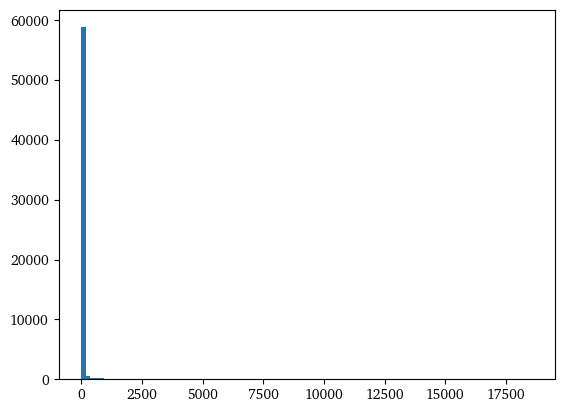

In [233]:
plt.hist(flux_kurt, bins=100)
plt.show()

#### Plot all embeddings as sanity check, with interesting groups

In [234]:
umap1_emb = data['embedding'][:,0]
umap2_emb = data['embedding'][:,1]


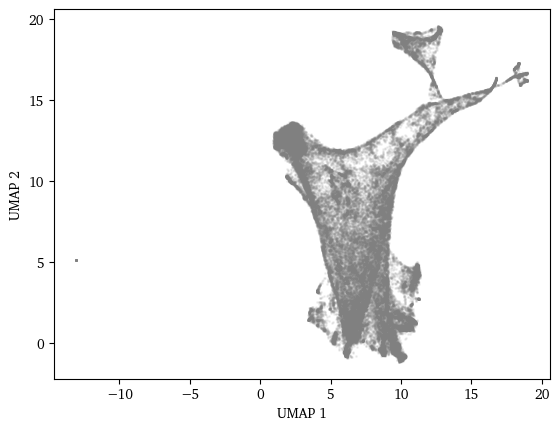

In [235]:
plt.scatter(umap1_emb, umap2_emb, s=1, alpha=0.1,color='grey')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

## Colour coding by properties

### Plot of chosen statistics for paper

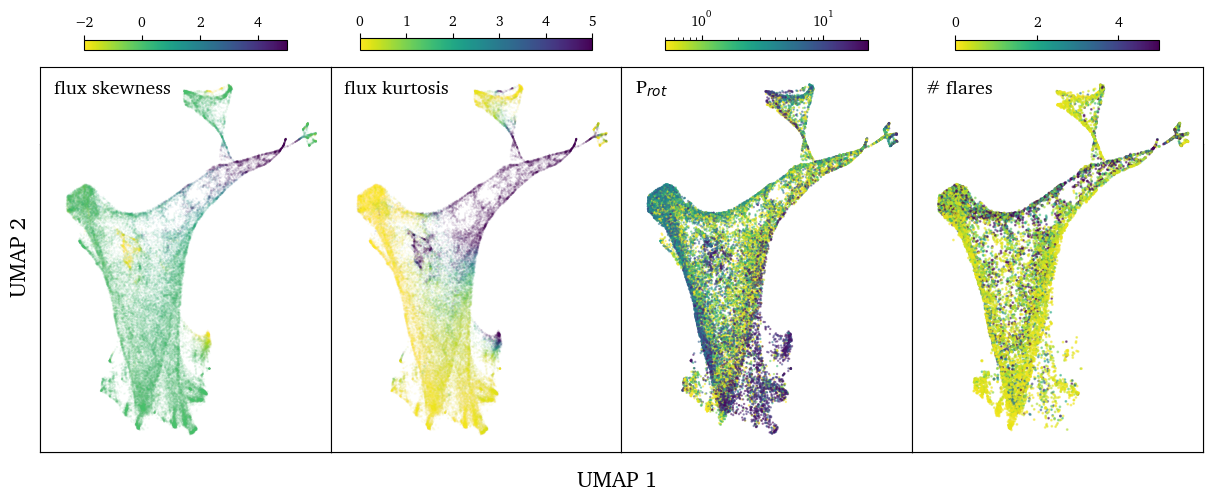

In [ ]:
fig,ax = plt.subplots(1,4,figsize=(15, 5),sharey=True,gridspec_kw={'wspace': 0})

plt.subplot(1,4,1,sharey=ax[0])
plt.scatter(umap1_emb, umap2_emb, s=0.1, c=flux_skew, cmap='viridis_r',
            norm=Normalize(vmin=-2, vmax=5), alpha=0.1)
norm=Normalize(vmin=-2, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')
cbar = fig.colorbar(sm, ax=ax[0], shrink=0.7, location='top', orientation='horizontal')
pos = cbar.ax.get_position()
cbar.ax.set_position([
    pos.x0,   # left shift
    pos.y0 + 0.15,
    pos.width,
    pos.height
])
plt.xlim(-1,20)
plt.text(0,19,'flux skewness',fontsize=14)
plt.xticks([])

plt.subplot(1,4,2,sharey=ax[0])
plt.scatter(umap1_emb, umap2_emb, s=0.1, c=flux_kurt, cmap='viridis_r',
            norm=Normalize(vmin=0, vmax=5), alpha=0.1)
norm=Normalize(vmin=0, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')
cbar = fig.colorbar(sm, ax=ax[1], shrink=0.8, location='top', orientation='horizontal')
pos = cbar.ax.get_position()
cbar.ax.set_position([
    pos.x0,   # left shift
    pos.y0 + 0.15,
    pos.width,
    pos.height
])
cbar.ax.tick_params(labelsize=10)
plt.text(0,19,'flux kurtosis',fontsize=14)
plt.yticks([])
plt.xticks([])
plt.xlim(-1,20)

plt.subplot(1,4,3,sharey=ax[0])
plt.scatter(umap1_emb, umap2_emb, s=0.5, c=tars_Prot, cmap='viridis_r',
            norm=LogNorm(vmin=0.5, vmax=np.nanmax(tars_Prot)), alpha=0.5)
plt.text(0,19,r'P$_{rot}$',fontsize=14)
norm=LogNorm(vmin=0.5, vmax=np.nanmax(tars_Prot))
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')
cbar = fig.colorbar(sm,ax=ax[2],orientation='horizontal',location='top',shrink=0.7)
pos = cbar.ax.get_position()
cbar.ax.set_position([
    pos.x0,   # left shift
    pos.y0 + 0.15,
    pos.width,
    pos.height
])
cbar.ax.tick_params(labelsize=10)
plt.yticks([])
plt.xticks([])
plt.xlim(-1,20)

plt.subplot(1,4,4,sharey=ax[0])
plt.scatter(umap1_emb, umap2_emb, s=1, c=num_flares, cmap='viridis_r',
            norm=Normalize(vmin=0, vmax=50), alpha=0.5)
norm=Normalize(vmin=0, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')
cbar = fig.colorbar(sm, ax=ax[3], shrink=0.7,location='top', orientation='horizontal')
pos = cbar.ax.get_position()
cbar.ax.set_position([
    pos.x0,   # left shift
    pos.y0 + 0.15,
    pos.width,
    pos.height
])
cbar.ax.tick_params(labelsize=10)
plt.text(0,19,r'# flares',fontsize=14)
plt.yticks([])
plt.xticks([])
plt.xlim(-1,20)

fig.supxlabel('UMAP 1',fontsize=16,y=0.03,x=0.51)
fig.supylabel('UMAP 2',fontsize=16,x=0.105)
ax[0].set_xticks([])
ax[1].set_xticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])

plt.show()

#### Age

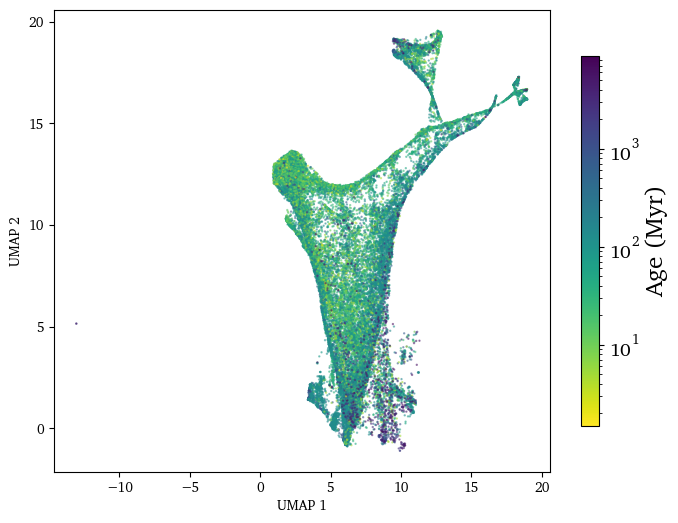

In [236]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=0.5, c=ages, cmap='viridis_r',
            norm=LogNorm(vmin=np.nanmin(ages), vmax=np.nanmax(ages)), alpha=0.5)
    
norm=LogNorm(vmin=np.nanmin(ages), vmax=np.nanmax(ages))
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Age (Myr)', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

### Rotation

#### Literature

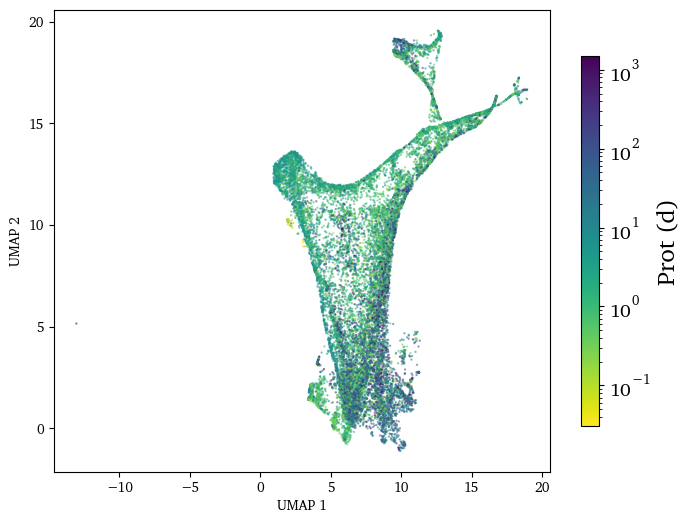

In [237]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=0.5, c=lit_Prot, cmap='viridis_r',
            norm=LogNorm(vmin=np.nanmin(lit_Prot), vmax=np.nanmax(lit_Prot)), alpha=0.5)
    
norm=LogNorm(vmin=np.nanmin(lit_Prot), vmax=np.nanmax(lit_Prot))
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Prot (d)', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

#### TARS

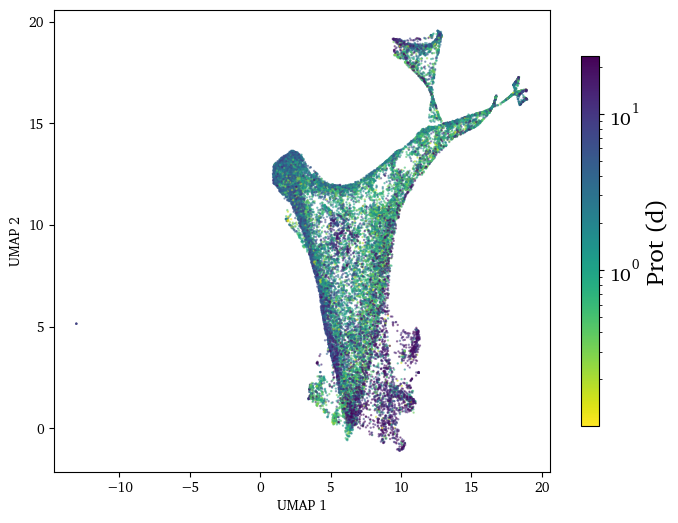

In [238]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=0.5, c=tars_Prot, cmap='viridis_r',
            norm=LogNorm(vmin=np.nanmin(tars_Prot), vmax=np.nanmax(tars_Prot)), alpha=0.5)
    
norm=LogNorm(vmin=np.nanmin(tars_Prot), vmax=np.nanmax(tars_Prot))
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Prot (d)', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

##### Bin rotation period

In [268]:
mask_fast = np.array(tars_Prot) < 1
mask_medium = (np.array(tars_Prot) >= 1) & (np.array(tars_Prot) < 5)
mask_slow = np.array(tars_Prot) >= 5


In [271]:
np.count_nonzero(mask_slow)

np.int64(8241)

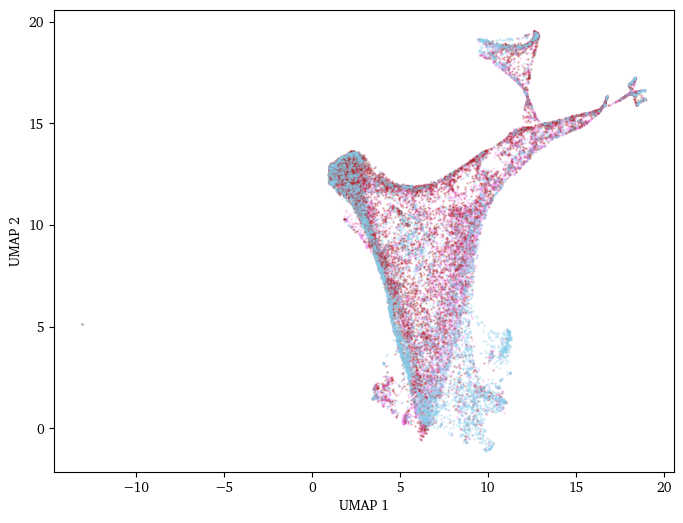

In [291]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb[mask_fast], umap2_emb[mask_fast], s=0.5, c='violet', alpha=0.3)
plt.scatter(umap1_emb[mask_medium], umap2_emb[mask_medium], s=0.5, c='firebrick', alpha=0.3)
plt.scatter(umap1_emb[mask_slow], umap2_emb[mask_slow], s=0.5, c='skyblue', alpha=0.3)

# norm=LogNorm(vmin=np.nanmin(tars_Prot), vmax=np.nanmax(tars_Prot))
# sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

# cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
# cbar.set_label('Prot (d)', fontsize=18)
# cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

### Flux Distribution Summary Statistics

#### Skewness

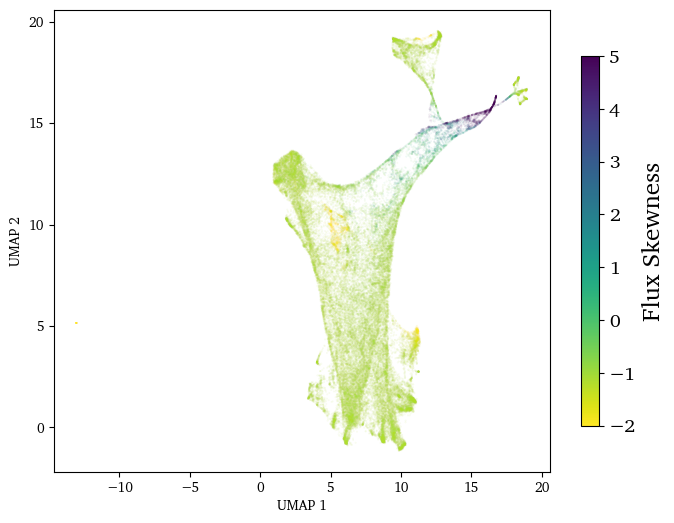

In [239]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=0.1, c=flux_skew, cmap='viridis_r',
            norm=Normalize(vmin=-2, vmax=15), alpha=0.1)
    
norm=Normalize(vmin=-2, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Flux Skewness', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

### Kurtosis

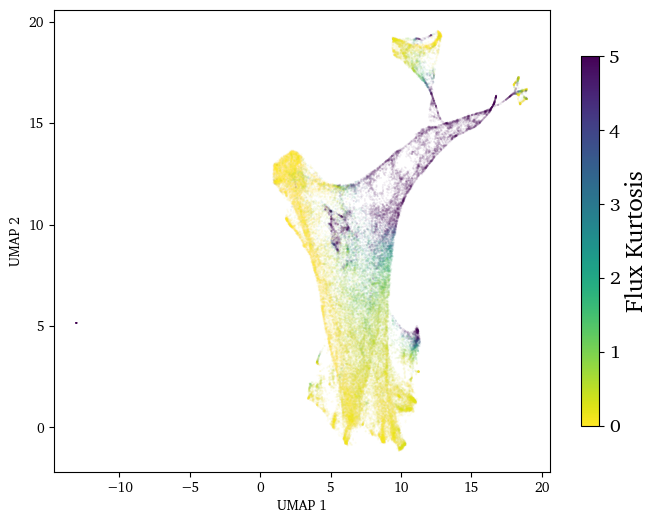

In [240]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=0.1, c=flux_kurt, cmap='viridis_r',
            norm=Normalize(vmin=0, vmax=5), alpha=0.1)
    
norm=Normalize(vmin=0, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Flux Kurtosis', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

### Flare statistics

#### Total Equivalent Duration

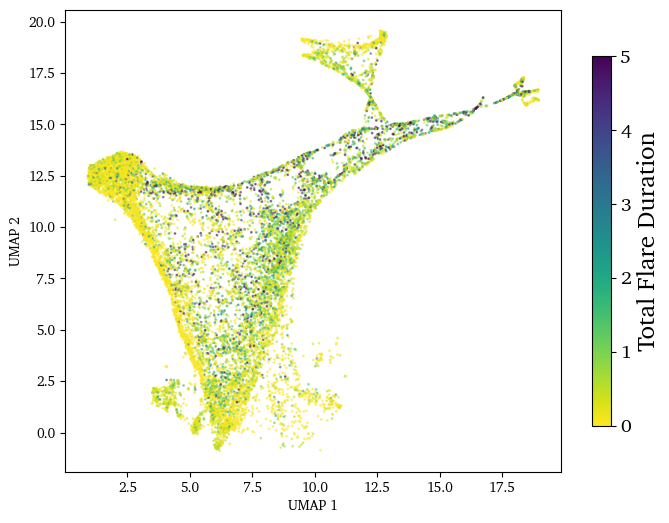

In [ ]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=1, c=total_flare_ed, cmap='viridis_r',
            norm=Normalize(vmin=0, vmax=200), alpha=0.5)
    
norm=Normalize(vmin=0, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Total Flare Duration from F+24', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

#### Number of flares

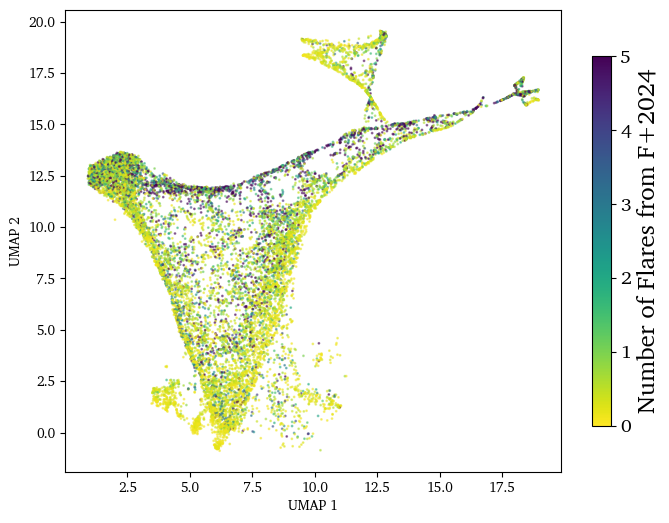

In [245]:
fig,ax = plt.subplots(figsize=(8, 6))

plt.scatter(umap1_emb, umap2_emb, s=1, c=num_flares, cmap='viridis_r',
            norm=Normalize(vmin=0, vmax=50), alpha=0.5)
    
norm=Normalize(vmin=0, vmax=5)
sm = cm.ScalarMappable(norm=norm, cmap='viridis_r')

cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Number of Flares from F+2024', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

## Interesting groups of stars

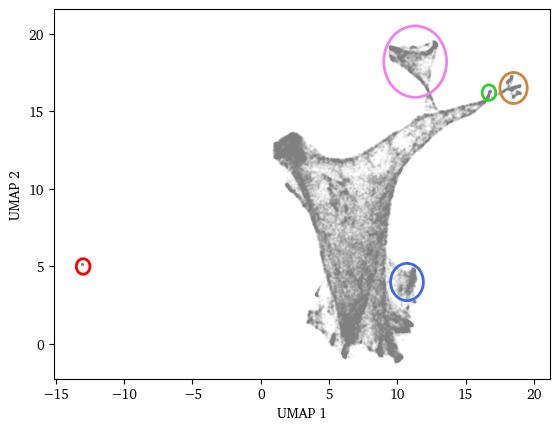

In [217]:
x1, y1 = -13, 5
x2, y2 = 18.5, 16.5
x3, y3 = 11.3, 18.2
x4, y4 = 10.7, 4
x5, y5 = 16.7,16.2
r1 = 0.5
r2 = 1
r3 = 2.3
r4 = 1.2
r5 = 0.5
c1 = 'red'
c2 = 'peru'
c3 = 'violet'
c4 = 'royalblue'
c5 = 'limegreen'

circle1 = Circle(
    (x1, y1),      # center
    radius=r1,    # radius in data units
    edgecolor=c1,
    facecolor='none',   # transparent fill
    linewidth=2
)

circle2 = Circle(
    (x2, y2),      # center
    radius=r2,    # radius in data units
    edgecolor=c2,
    facecolor='none',   # transparent fill
    linewidth=2
)

circle3 = Circle(
    (x3, y3),      # center
    radius=r3,    # radius in data units
    edgecolor=c3,
    facecolor='none',   # transparent fill
    linewidth=2
)

circle4 = Circle(
    (x4, y4),      # center
    radius=r4,    # radius in data units
    edgecolor=c4,
    facecolor='none',   # transparent fill
    linewidth=2
)

circle5 = Circle(
    (x5, y5),      # center
    radius=r5,    # radius in data units
    edgecolor=c5,
    facecolor='none',   # transparent fill
    linewidth=2
)

plt.scatter(umap1_emb, umap2_emb, s=1, alpha=0.05,color='grey')
plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)
plt.gca().add_patch(circle3)
plt.gca().add_patch(circle4)
plt.gca().add_patch(circle5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

### Cut to interesting regions - CMD

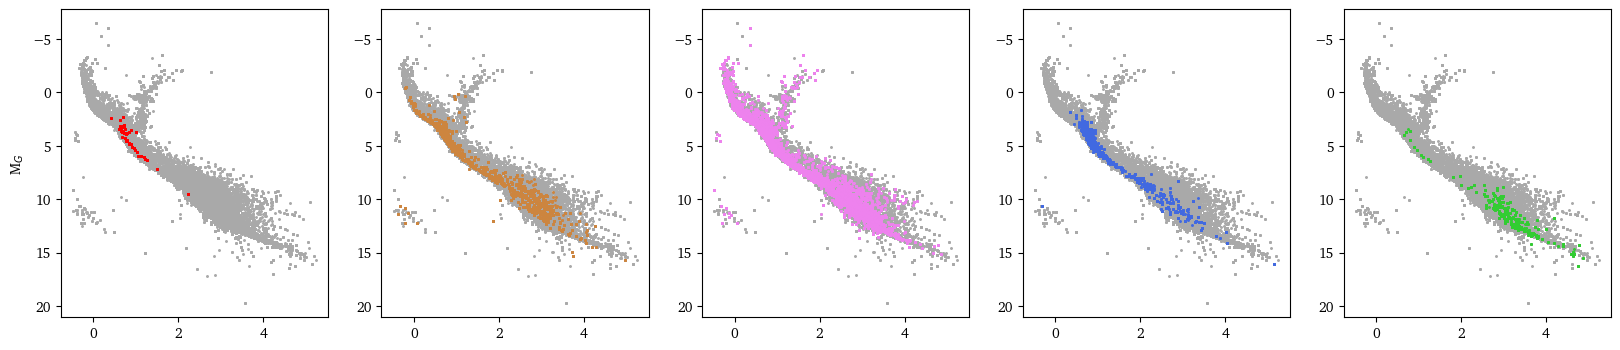

In [218]:
mask1 = (umap1_emb - x1)**2 + (umap2_emb - y1)**2 <= r1**2
gids1 = gaia_ids[mask1]
mask2 = (umap1_emb - x2)**2 + (umap2_emb - y2)**2 <= r2**2
gids2 = gaia_ids[mask2]
mask3 = (umap1_emb - x3)**2 + (umap2_emb - y3)**2 <= r3**2
gids3 = gaia_ids[mask3]
mask4 = (umap1_emb - x4)**2 + (umap2_emb - y4)**2 <= r4**2
gids4 = gaia_ids[mask4]
mask5 = (umap1_emb - x5)**2 + (umap2_emb - y5)**2 <= r5**2
gids5 = gaia_ids[mask5]

fig,ax = plt.subplots(1,5, figsize=(20, 4))

plt.subplot(1,5,1)

# All stars for reference
plt.scatter(df['BPRP0'],df['MG'], s=5, alpha=1,c='darkgray',marker='.')
# Region 1
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids1)]
plt.scatter(df_region['BPRP0'],df_region['MG'], s=5, alpha=1,c=c1,marker='.')
plt.gca().invert_yaxis()
plt.ylabel(r'M$_G$')

plt.subplot(1,5,2)
# All stars for reference
plt.scatter(df['BPRP0'],df['MG'], s=5, alpha=1,c='darkgray',marker='.')
# Region 2
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids2)]
plt.scatter(df_region['BPRP0'],df_region['MG'], s=5, alpha=1,c=c2,marker='.')
plt.gca().invert_yaxis()

plt.subplot(1,5,3)
# All stars for reference
plt.scatter(df['BPRP0'],df['MG'], s=5, alpha=1,c='darkgray',marker='.')
# Region 3
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids3)]
plt.scatter(df_region['BPRP0'],df_region['MG'], s=5, alpha=1,c=c3,marker='.')
plt.gca().invert_yaxis()

plt.subplot(1,5,4)
# All stars for reference
plt.scatter(df['BPRP0'],df['MG'], s=5, alpha=1,c='darkgray',marker='.')
# Region 4
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids4)]
plt.scatter(df_region['BPRP0'],df_region['MG'], s=5, alpha=1,c=c4,marker='.')
plt.gca().invert_yaxis()

plt.subplot(1,5,5)
# All stars for reference
plt.scatter(df['BPRP0'],df['MG'], s=5, alpha=1,c='darkgray',marker='.')
# Region 5
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids5)]
plt.scatter(df_region['BPRP0'],df_region['MG'], s=5, alpha=1,c=c5,marker='.')
plt.gca().invert_yaxis()


plt.show()

### Interesting regios - $P_{rot}$

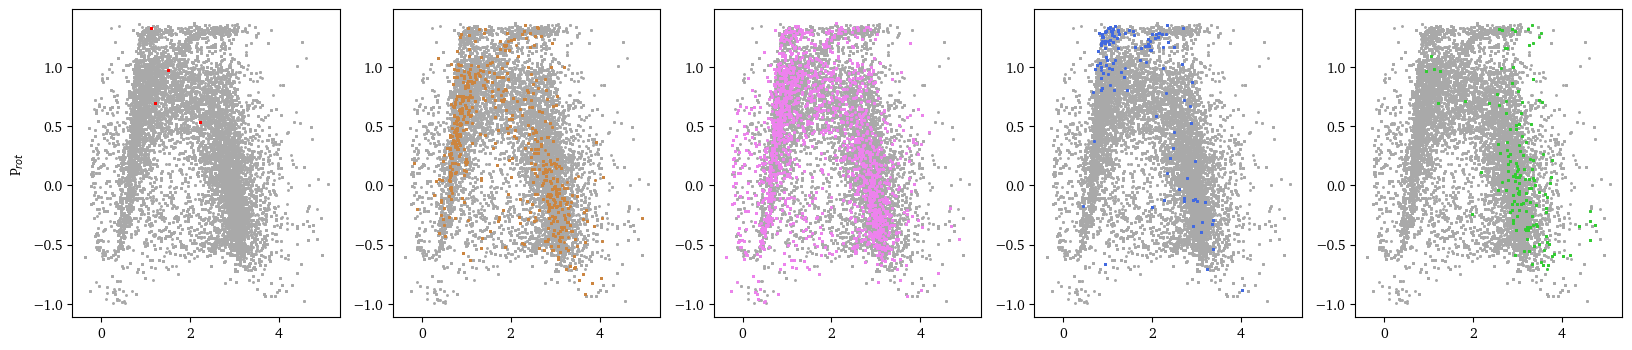

In [380]:
mask1 = (umap1_emb - x1)**2 + (umap2_emb - y1)**2 <= r1**2
gids1 = gaia_ids[mask1]
mask2 = (umap1_emb - x2)**2 + (umap2_emb - y2)**2 <= r2**2
gids2 = gaia_ids[mask2]
mask3 = (umap1_emb - x3)**2 + (umap2_emb - y3)**2 <= r3**2
gids3 = gaia_ids[mask3]
mask4 = (umap1_emb - x4)**2 + (umap2_emb - y4)**2 <= r4**2
gids4 = gaia_ids[mask4]
mask5 = (umap1_emb - x5)**2 + (umap2_emb - y5)**2 <= r5**2
gids5 = gaia_ids[mask5]

fig,ax = plt.subplots(1,5, figsize=(20, 4))

plt.subplot(1,5,1)

# All stars for reference
plt.scatter(df['BPRP0'],np.log10(df['tars_Prot']), s=5, alpha=1,c='darkgray',marker='.')
# Region 1
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids1)]
plt.scatter(df_region['BPRP0'],np.log10(df_region['tars_Prot']), s=5, alpha=1,c=c1,marker='.')
plt.ylabel(r'P$_{rot}$')

plt.subplot(1,5,2)
# All stars for reference
plt.scatter(df['BPRP0'],np.log10(df['tars_Prot']), s=5, alpha=1,c='darkgray',marker='.')
# Region 2
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids2)]
plt.scatter(df_region['BPRP0'],np.log10(df_region['tars_Prot']), s=5, alpha=1,c=c2,marker='.')    

plt.subplot(1,5,3)
# All stars for reference
plt.scatter(df['BPRP0'],np.log10(df['tars_Prot']), s=5, alpha=1,c='darkgray',marker='.')
# Region 3
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids3)]
plt.scatter(df_region['BPRP0'],np.log10(df_region['tars_Prot']), s=5, alpha=1,c=c3,marker='.')

plt.subplot(1,5,4)
# All stars for reference
plt.scatter(df['BPRP0'],np.log10(df['tars_Prot']), s=5, alpha=1,c='darkgray',marker='.')
# Region 4
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids4)]
plt.scatter(df_region['BPRP0'],np.log10(df_region['tars_Prot']), s=5, alpha=1,c=c4,marker='.')

plt.subplot(1,5,5)
# All stars for reference
plt.scatter(df['BPRP0'],np.log10(df['tars_Prot']), s=5, alpha=1,c='darkgray',marker='.')
# Region 5
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(gids5)]
plt.scatter(df_region['BPRP0'],np.log10(df_region['tars_Prot']), s=5, alpha=1,c=c5,marker='.')


plt.show()

## Look at sample light curves

### Choose random stars from specific regions of UMAP space as an example

#### Bottom left

In [236]:
random_gid

'661283199601699328'

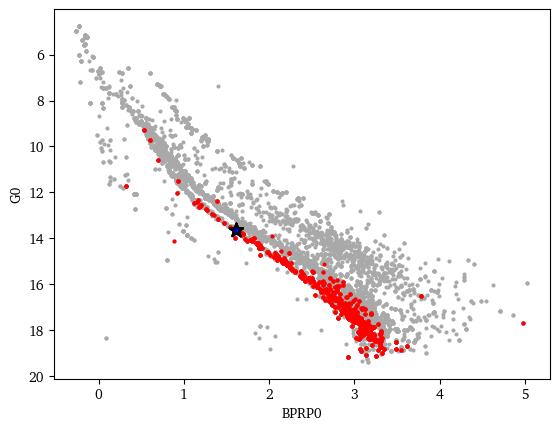

In [4]:
mask_x = (embedding[:, 0] < 0)
mask_y = (embedding[:, 1] < -2)
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_index = np.random.choice(matching_indices[0])
random_gid = gaia_ids[random_index]
random_gid_1 = '661283199601699328'
random_index_1 = 4447


# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_1, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_1, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Top blob

In [5]:
random_gid

np.str_('661416274866976384')

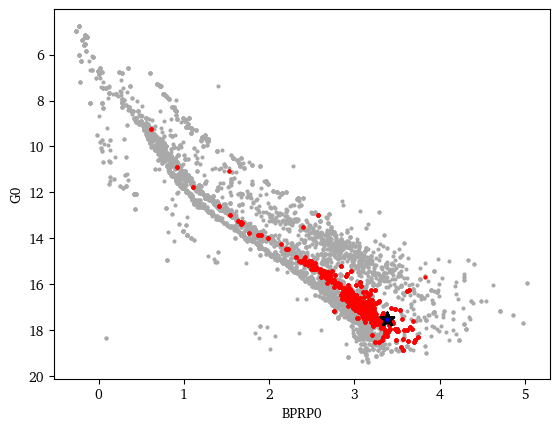

In [6]:
mask_x = (embedding[:, 0] < 4) & (embedding[:, 0] > 2)
mask_y = embedding[:, 1] > 6
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_2 = '68283421593270400'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_2, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_2, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Right (young)

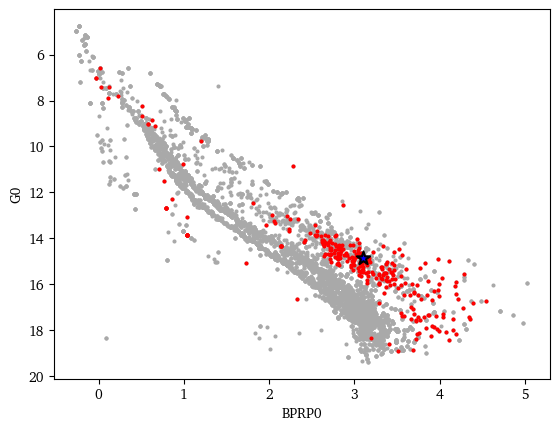

In [7]:
mask_x = (embedding[:, 0] < 8) & (embedding[:, 0] > 7)
mask_y = embedding[:, 1] > 4
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_3 = '6050538893392363136'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_3, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_3, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

#### Middle

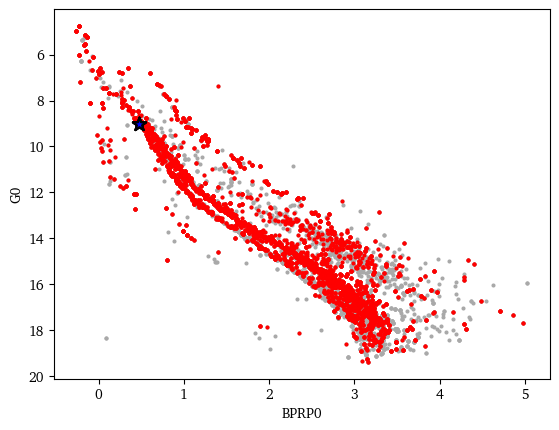

In [8]:
mask_x = (embedding[:, 0] < 10) & (embedding[:, 0] > 2)
mask_y = (embedding[:, 1] > -2) & (embedding[:, 1] < 4)
matching_indices = np.where(mask_x & mask_y)
matching_gids = gaia_ids[matching_indices]
random_gid = np.random.choice(matching_gids)
random_gid_4 = '659466222275521792'

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
plt.scatter(df.loc[df['GaiaDR3_ID'] == random_gid_4, 'BPRP0'], df.loc[df['GaiaDR3_ID'] == random_gid_4, 'G0'],
            s=100, alpha=1, c='blue', marker='*', edgecolor='black', linewidth=1.5, label='Random Star')
plt.gca().invert_yaxis()
plt.xlabel('BPRP0')
plt.ylabel('G0')
plt.show()

### Plot latent space

In [9]:
def umap_scatter(c, label, log_scale=False, cmap='viridis_r',
                 bprp0_min=None, bprp0_max=None,
                 point_size=10, alpha=0.5, figsize=(10, 6)):
    """Plot UMAP colored by an arbitrary array, with optional BPRP0 filtering."""
    c = np.asarray(c, dtype=float)
    mask = np.ones(len(embedding), dtype=bool)
    if bprp0_min is not None:
        mask &= (bprp0 >= bprp0_min)
    if bprp0_max is not None:
        mask &= (bprp0 <= bprp0_max)
    mask &= ~np.isnan(c)

    x_p = embedding[mask, 0]
    y_p = embedding[mask, 1]
    c_p = c[mask]

    norm = LogNorm(vmin=c_p.min(), vmax=c_p.max()) if log_scale else Normalize(vmin=c_p.min(), vmax=c_p.max())

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(x_p, y_p, c=c_p, cmap=cmap, norm=norm,
                    s=point_size, alpha=alpha, rasterized=True)
    
    # Set colorbar on separate points to have separate alpha
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label(label, fontsize=18)
    cbar.ax.tick_params(labelsize=14)
    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

    info_lines = [f'N = {mask.sum()}']
    if bprp0_min is not None or bprp0_max is not None:
        info_lines.append(f'BPRP0: {bprp0_min or ""}–{bprp0_max or ""}')
    # ax.text(0.02, 0.98, '\n'.join(info_lines), transform=ax.transAxes, fontsize=11,
    #         va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    return fig, ax

### Stellar age

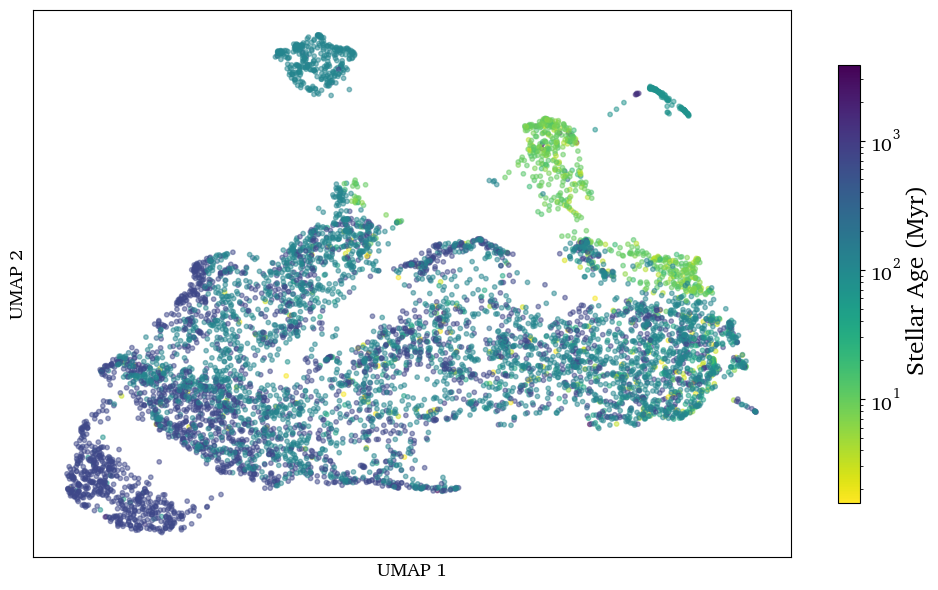

In [10]:
fig, ax = umap_scatter(ages, ' Stellar Age (Myr)', log_scale=True)
# ax.set_title('UMAP – Stellar Age')


plt.show()

### Age with BPRP0 filter to restrict the plotted points to a colour range.

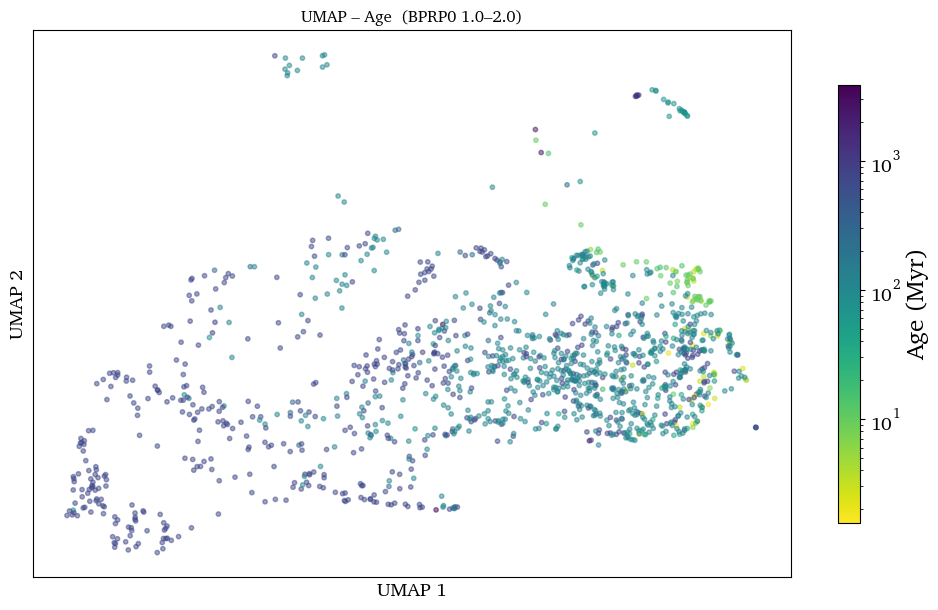

In [11]:
fig, ax = umap_scatter(ages, 'Age (Myr)', log_scale=True,
                       bprp0_min=1.0, bprp0_max=2.0)
ax.set_title('UMAP – Age  (BPRP0 1.0–2.0)')
plt.show()

### BPRP0 color

/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_93417/1598810239.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Charter.
  plt.tight_layout()
/Users/philvanlane/opt/anaconda3/envs/default-py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)


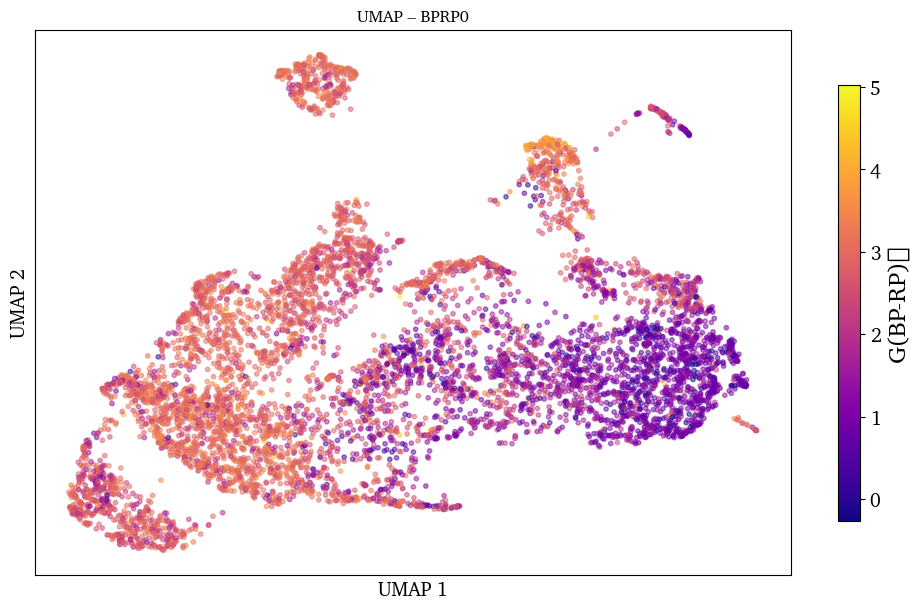

In [14]:
fig, ax = umap_scatter(bprp0, 'G(BP-RP)₀', log_scale=False, cmap='plasma')
ax.set_title('UMAP – BPRP0')
plt.show()

### Color by any phot_all.csv column `Prot`, `parallax`, `G0`, `BP0`, `RP0`, `teff_gspphot`, etc.

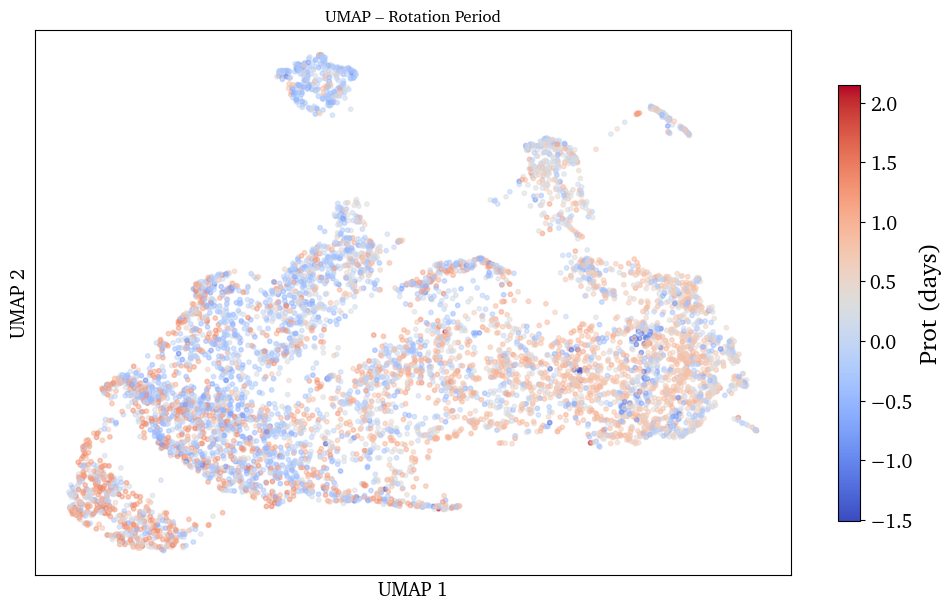

In [55]:
# Example: rotation period
fig, ax = umap_scatter(np.log10(df['Prot'].values), 'Prot (days)', log_scale=False, cmap='coolwarm')
ax.set_title('UMAP – Rotation Period')
plt.show()

## Find CMD examples

In [12]:
# Blue, bright, 97 Myr
dr3id_1 = '64933759417769984'

# Red, maybe PMS, 760 Myr
dr3id_2 = '145668974102570624'

# Red 718 Myr
dr3id_3 = '658156527832150400'

In [13]:
df_1 = df.loc[(df['GaiaDR3_ID'] == random_gid_1)]
BPRP0_1 = df_1['BPRP0'].values[0]
G0_1 = df_1['G0'].values[0]

df_2 = df.loc[(df['GaiaDR3_ID'] == random_gid_2)]
BPRP0_2 = df_2['BPRP0'].values[0]
G0_2 = df_2['G0'].values[0]

df_3 = df.loc[(df['GaiaDR3_ID'] == random_gid_3)]
BPRP0_3 = df_3['BPRP0'].values[0]
G0_3 = df_3['G0'].values[0]

df_4 = df.loc[(df['GaiaDR3_ID'] == random_gid_4)]
BPRP0_4 = df_4['BPRP0'].values[0]
G0_4 = df_4['G0'].values[0]

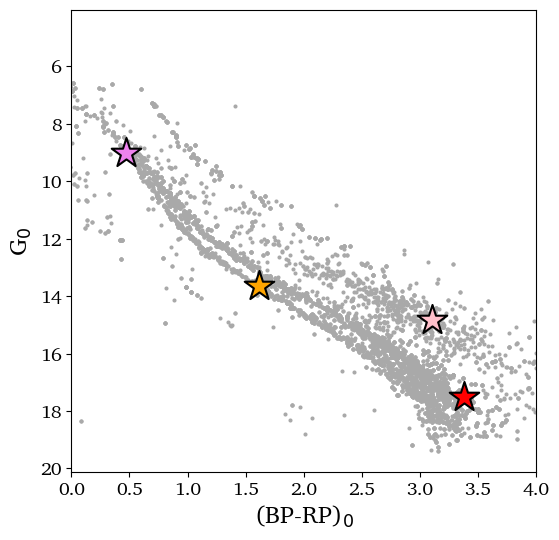

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')

plt.scatter(BPRP0_1, G0_1, s=500, alpha=1, c='orange',marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_2, G0_2, s=500, alpha=1, c='red', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_3, G0_3, s=500, alpha=1, c='pink', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_4, G0_4, s=500, alpha=1, c='violet', marker='*', edgecolor='black', linewidth=1.5)

plt.gca().invert_yaxis()
plt.xlim(0,4)
plt.xlabel(r'(BP-RP)$_0$',fontsize=18)
plt.ylabel(r'G$_0$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

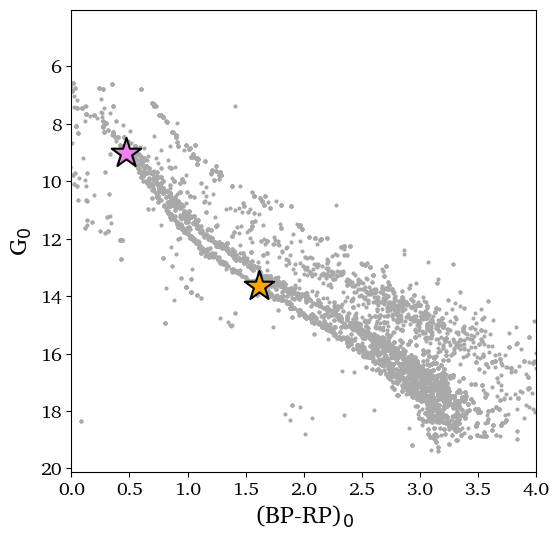

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')

plt.scatter(BPRP0_1, G0_1, s=500, alpha=1, c='orange',marker='*', edgecolor='black', linewidth=1.5)
# plt.scatter(BPRP0_2, G0_2, s=500, alpha=1, c='red', marker='*', edgecolor='black', linewidth=1.5)
# plt.scatter(BPRP0_3, G0_3, s=500, alpha=1, c='red', marker='*', edgecolor='black', linewidth=1.5)
plt.scatter(BPRP0_4, G0_4, s=500, alpha=1, c='violet', marker='*', edgecolor='black', linewidth=1.5)

plt.gca().invert_yaxis()
plt.xlim(0,4)
plt.xlabel(r'(BP-RP)$_0$',fontsize=18)
plt.ylabel(r'G$_0$',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

### Plot UMAP with specific points

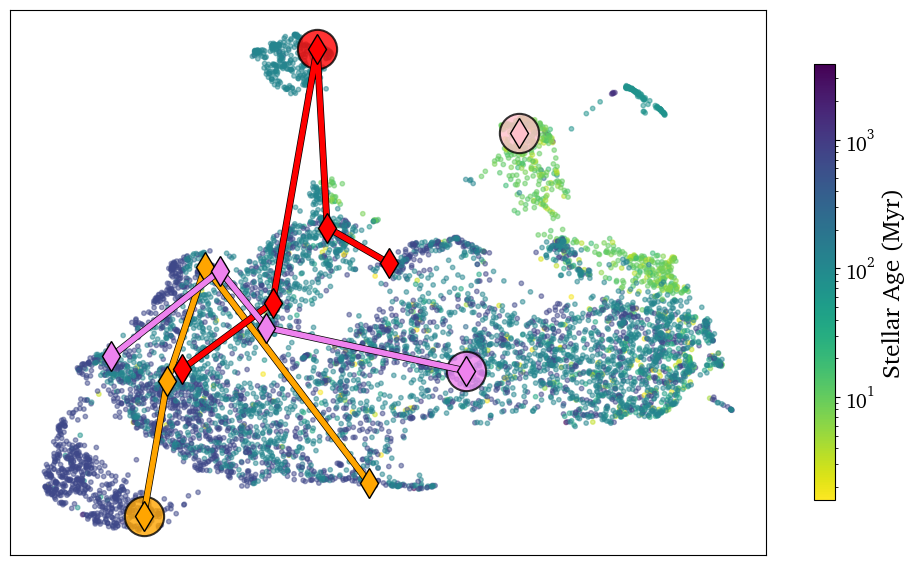

In [29]:
fig, ax = umap_scatter(ages, 'Stellar Age (Myr)', log_scale=True)
# ax.set_title('UMAP – Stellar Age')
umap_ind_1 = np.where(gaia_ids == random_gid_1)[0]
umap_ind_2 = np.where(gaia_ids == random_gid_2)[0]
umap_ind_3 = np.where(gaia_ids == random_gid_3)[0]
umap_ind_4 = np.where(gaia_ids == random_gid_4)[0]

umap_1 = embedding[umap_ind_1]
umap_1_sorted = umap_1[umap_1[:, 0].argsort()]
plt.scatter(umap_1_sorted[0,0], umap_1_sorted[0,1], s=800, alpha=0.8,
            color='orange', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='orange', marker='d',
            markeredgecolor='black',linewidth=4)

umap_2 = embedding[umap_ind_2]
umap_2_sorted = umap_2[umap_2[:, 0].argsort()]
plt.scatter(umap_2_sorted[2,0], umap_2_sorted[2,1], s=800, alpha=0.8,
            color='red', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='red', marker='d',
            markeredgecolor='black',linewidth=4)

umap_3 = embedding[umap_ind_3]
umap_3_sorted = umap_3[umap_3[:, 0].argsort()]
plt.scatter(umap_3_sorted[0,0], umap_3_sorted[0,1], s=800, alpha=0.8,
            color='pink', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='pink', marker='d',
            markeredgecolor='black',linewidth=4)

umap_4 = embedding[umap_ind_4]
umap_4_sorted = umap_4[umap_4[:, 0].argsort()]
plt.scatter(umap_4_sorted[3,0], umap_4_sorted[3,1], s=800, alpha=0.8,
            color='violet', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='violet', marker='d',
            markeredgecolor='black',linewidth=4)

ax.set_xlabel('', fontsize=18)
ax.set_ylabel('', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

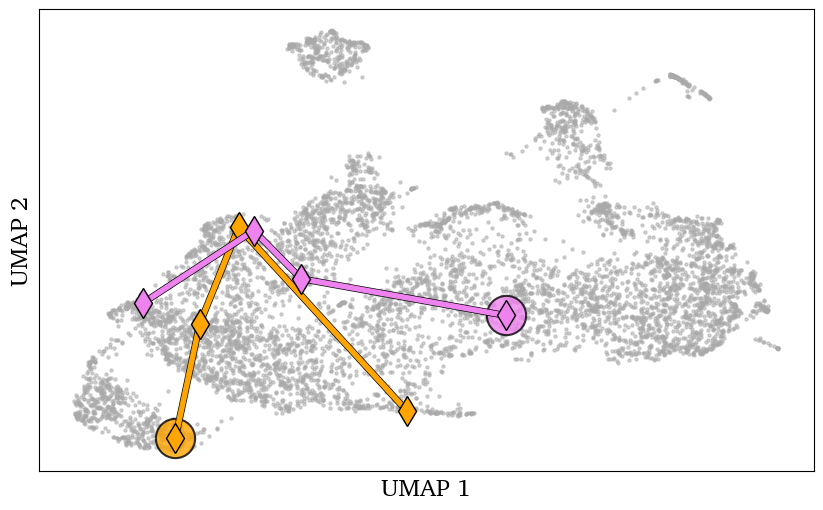

In [33]:
# fig, ax = umap_scatter(ages,label='Stellar Age (Myr)', log_scale=True)

fig, ax = plt.subplots(figsize=(10, 6))
x_all = embedding[:, 0]
y_all = embedding[:, 1]
sc = ax.scatter(x_all,y_all, color='darkgrey', s=20, alpha=0.5, marker='.')
# ax.set_title('UMAP – Stellar Age')
umap_ind_1 = np.where(gaia_ids == random_gid_1)[0]
umap_ind_2 = np.where(gaia_ids == random_gid_2)[0]
umap_ind_3 = np.where(gaia_ids == random_gid_3)[0]
umap_ind_4 = np.where(gaia_ids == random_gid_4)[0]

umap_1 = embedding[umap_ind_1]
umap_1_sorted = umap_1[umap_1[:, 0].argsort()]
plt.scatter(umap_1_sorted[0,0], umap_1_sorted[0,1], s=800, alpha=0.8,
            color='orange', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='orange', marker='d',
            markeredgecolor='black',linewidth=4)

# umap_2 = embedding[umap_ind_2]
# umap_2_sorted = umap_2[umap_2[:, 0].argsort()]
# plt.scatter(umap_2_sorted[2,0], umap_2_sorted[2,1], s=800, alpha=0.8,
#             color='red', marker='o',edgecolor='black', linewidth=1.5)
# plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], color='black', linewidth=5)
# plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], markersize=15, alpha=1,
#             linestyle='-', color='red', marker='d',
#             markeredgecolor='black',linewidth=4)

# umap_3 = embedding[umap_ind_3]
# umap_3_sorted = umap_3[umap_3[:, 0].argsort()]
# plt.scatter(umap_3_sorted[0,0], umap_3_sorted[0,1], s=800, alpha=0.8,
#             color='red', marker='o',edgecolor='black', linewidth=1.5)
# plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], color='black', linewidth=5)
# plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], markersize=15, alpha=1,
#             linestyle='-', color='red', marker='d',
#             markeredgecolor='black',linewidth=4)

umap_4 = embedding[umap_ind_4]
umap_4_sorted = umap_4[umap_4[:, 0].argsort()]
plt.scatter(umap_4_sorted[3,0], umap_4_sorted[3,1], s=800, alpha=0.8,
            color='violet', marker='o',edgecolor='black', linewidth=1.5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], color='black', linewidth=5)
plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], markersize=15, alpha=1,
            linestyle='-', color='violet', marker='d',
            markeredgecolor='black',linewidth=4)

ax.set_xlabel('UMAP 1', fontsize=18)
ax.set_ylabel('UMAP 2', fontsize=18)
plt.xticks([],fontsize=14)
plt.yticks([],fontsize=14)

plt.show()

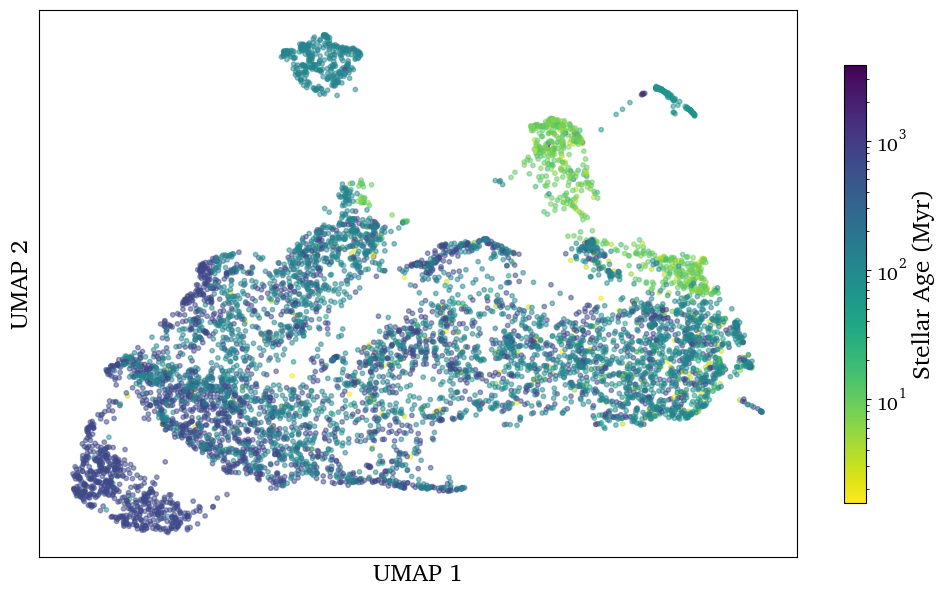

In [34]:
fig, ax = umap_scatter(ages,label='Stellar Age (Myr)', log_scale=True)

# ax.set_title('UMAP – Stellar Age')
umap_ind_1 = np.where(gaia_ids == random_gid_1)[0]
umap_ind_2 = np.where(gaia_ids == random_gid_2)[0]
umap_ind_3 = np.where(gaia_ids == random_gid_3)[0]
umap_ind_4 = np.where(gaia_ids == random_gid_4)[0]

# umap_1 = embedding[umap_ind_1]
# umap_1_sorted = umap_1[umap_1[:, 0].argsort()]
# plt.scatter(umap_1_sorted[0,0], umap_1_sorted[0,1], s=800, alpha=0.8,
#             color='orange', marker='o',edgecolor='black', linewidth=1.5)
# plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], color='black', linewidth=5)
# plt.plot(umap_1_sorted[:,0], umap_1_sorted[:,1], markersize=15, alpha=1,
#             linestyle='-', color='orange', marker='d',
#             markeredgecolor='black',linewidth=4)

# umap_2 = embedding[umap_ind_2]
# umap_2_sorted = umap_2[umap_2[:, 0].argsort()]
# plt.scatter(umap_2_sorted[2,0], umap_2_sorted[2,1], s=800, alpha=0.8,
#             color='red', marker='o',edgecolor='black', linewidth=1.5)
# plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], color='black', linewidth=5)
# plt.plot(umap_2_sorted[:,0], umap_2_sorted[:,1], markersize=15, alpha=1,
#             linestyle='-', color='red', marker='d',
#             markeredgecolor='black',linewidth=4)

# umap_3 = embedding[umap_ind_3]
# umap_3_sorted = umap_3[umap_3[:, 0].argsort()]
# plt.scatter(umap_3_sorted[0,0], umap_3_sorted[0,1], s=800, alpha=0.8,
#             color='red', marker='o',edgecolor='black', linewidth=1.5)
# plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], color='black', linewidth=5)
# plt.plot(umap_3_sorted[:,0], umap_3_sorted[:,1], markersize=15, alpha=1,
#             linestyle='-', color='red', marker='d',
#             markeredgecolor='black',linewidth=4)

# umap_4 = embedding[umap_ind_4]
# umap_4_sorted = umap_4[umap_4[:, 0].argsort()]
# plt.scatter(umap_4_sorted[3,0], umap_4_sorted[3,1], s=800, alpha=0.8,
#             color='violet', marker='o',edgecolor='black', linewidth=1.5)
# plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], color='black', linewidth=5)
# plt.plot(umap_4_sorted[:,0], umap_4_sorted[:,1], markersize=15, alpha=1,
#             linestyle='-', color='violet', marker='d',
#             markeredgecolor='black',linewidth=4)

ax.set_xlabel('UMAP 1', fontsize=18)
ax.set_ylabel('UMAP 2', fontsize=18)
plt.xticks([],fontsize=14)
plt.yticks([],fontsize=14)

plt.show()

## Get Example Light Curves

In [18]:
# Choose which points to use

umap_1_ref = umap_ind_1[1]      # left most orange point
umap_2_ref = umap_ind_2[0]      # top red point
umap_3_ref = umap_ind_3[0]      # pink point
umap_4_ref = umap_ind_4[0]      # right most yellow point

In [19]:
tic_1 = tic_ids[umap_1_ref]
sector_1 = sectors[umap_1_ref]
tic_2 = tic_ids[umap_2_ref]
sector_2 = sectors[umap_2_ref]
tic_3 = tic_ids[umap_3_ref]
sector_3 = sectors[umap_3_ref]
tic_4 = tic_ids[umap_4_ref]
sector_4 = sectors[umap_4_ref]

In [20]:
res_1 = lk.search_lightcurve(f"TIC {tic_1}", mission='TESS', author=['SPOC'],sector=sector_1,exptime=120)
lc_1 = res_1[0].download()
res_2 = lk.search_lightcurve(f"TIC {tic_2}", mission='TESS', author=['SPOC'],sector=sector_2,exptime=120)
lc_2 = res_2[0].download()
res_3 = lk.search_lightcurve(f"TIC {tic_3}", mission='TESS', author=['SPOC'],sector=sector_3,exptime=120)
lc_3 = res_3[0].download()
res_4 = lk.search_lightcurve(f"TIC {tic_4}", mission='TESS', author=['SPOC'],sector=sector_4,exptime=120)
lc_4 = res_4[0].download()

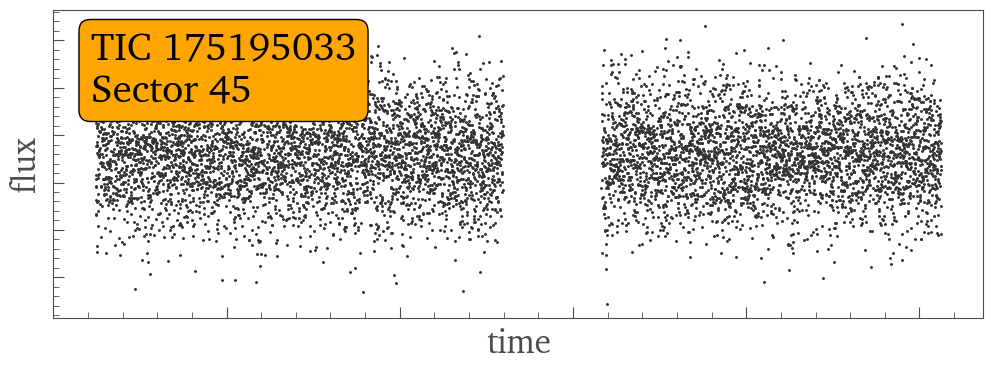

In [54]:
lc_thinned = lc_1[::2]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_1}\nSector {sector_1}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='orange', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

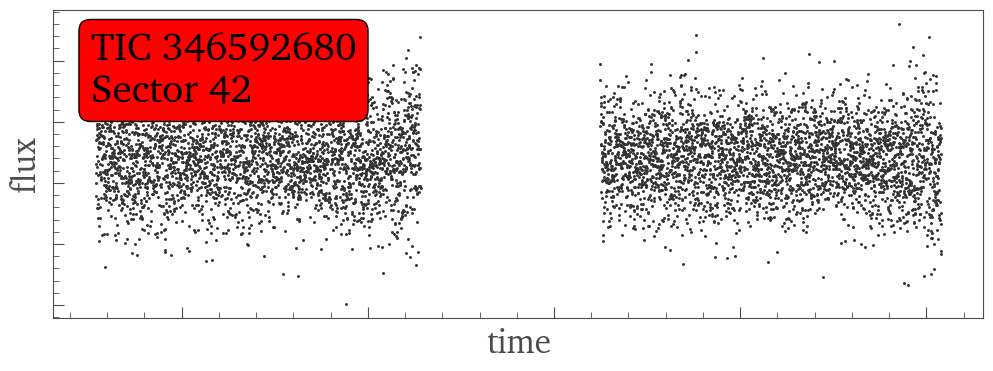

In [53]:
lc_thinned = lc_2[::2]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_2}\nSector {sector_2}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='red', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

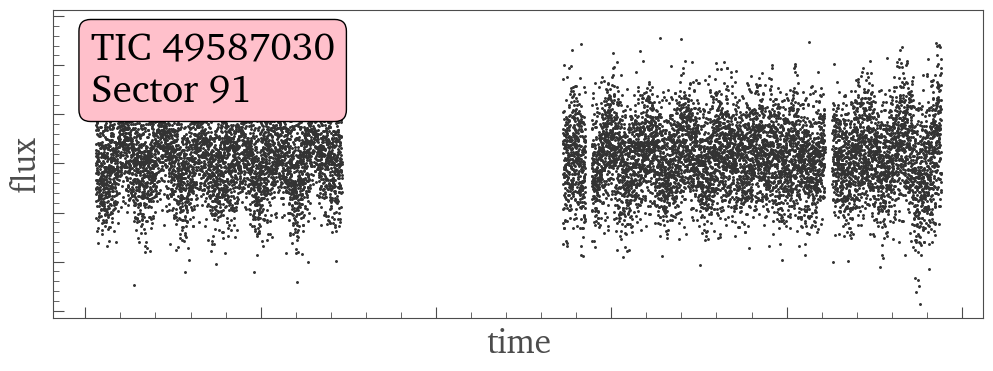

In [52]:
lc_thinned = lc_3[::1]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_3}\nSector {sector_3}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='pink', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

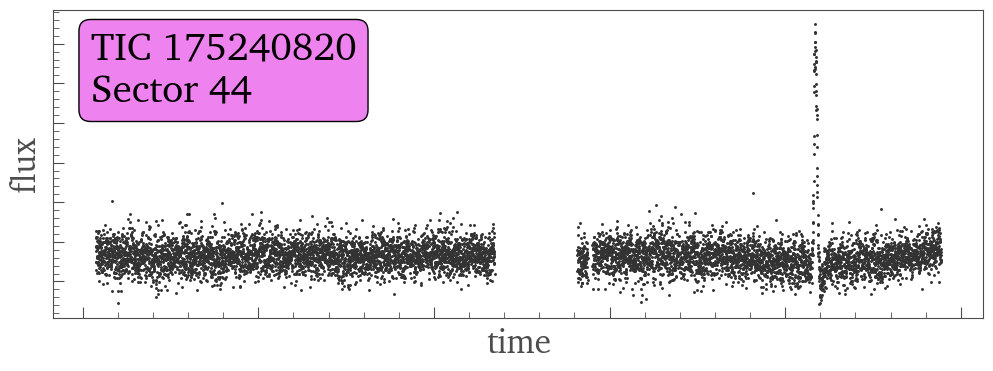

In [51]:
lc_thinned = lc_4[::2]
fig = lc_thinned.scatter(s=5,label='',marker='.')
fig.figure.set_size_inches(12, 4)
plt.text(0.04,0.93,f'TIC {tic_4}\nSector {sector_4}',fontsize=28,
         bbox=dict(boxstyle='round', facecolor='violet', alpha=1),ha='left',va='top',
         transform=plt.gca().transAxes)
xl = plt.gca().get_xlabel()
yl = plt.gca().get_ylabel()
plt.gca().set_xlabel('time',fontsize=24)
plt.gca().set_ylabel('flux',fontsize=24)
xtl = plt.gca().get_xticklabels()
ytl = plt.gca().get_yticklabels()
plt.gca().set_xticklabels([],fontsize=18)
plt.gca().set_yticklabels([],fontsize=18)
plt.show()

## Random plot for schematic

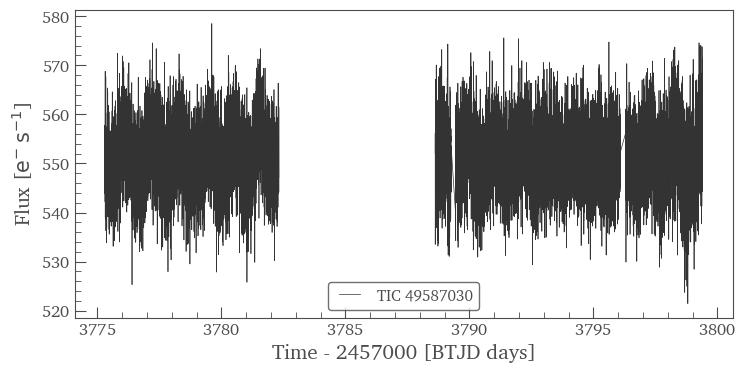

In [479]:
lc_3.plot()
plt.show()

In [483]:
phot.columns

Index(['GaiaDR3_ID', 'num_refs', 'Prot', 'age_Myr', 'parallax',
       'parallax_error', 'G0', 'G0_err', 'BP0', 'BP0_err', 'RP0', 'RP0_err',
       'BPRP0', 'BPRP0_err'],
      dtype='object')

In [490]:
df_test = df[['GaiaDR3_ID', 'tic','BPRP0']].sample(frac=0.1)
df_test['...'] = '...'
df_test

,GaiaDR3_ID,tic,BPRP0,...
6413,67054305033161344,149979913,2.975164,...
909,44388010264995200,435338054,3.645365,...
2452,64600813554014592,113982669,2.518392,...
1715,6049751196390570880,286075206,3.041236,...
2575,64891634380723712,440690662,2.194947,...
...,...,...,...,...
5993,66722660540945408,35156315,3.697476,...
4814,661486158278348160,331989648,3.083026,...
6954,69819027020489088,385552619,0.649584,...
1377,53251929411490688,14226920,2.463426,...


## Correlate points in UMAP space to parameters or Light Curve properties

In [99]:
def plot_umap_bounds(embedding, umap_xlim, umap_ylim):
    # Show bounding rectangle
    rect = patches.Rectangle(
        (umap_xlim[0], umap_ylim[0]),        # (x0, y0) lower-left corner
        umap_xlim[1] - umap_xlim[0],       # width
        umap_ylim[1] - umap_ylim[0],       # height
        edgecolor='navy',
        alpha=1,
        facecolor='none'
    )

    mask_x = (embedding[:, 0] < umap_xlim[1]) & (embedding[:, 0] > umap_xlim[0])
    mask_y = (embedding[:, 1] < umap_ylim[1]) & (embedding[:, 1] > umap_ylim[0])

    x_all = embedding[:, 0]
    y_all = embedding[:, 1]

    x_p = embedding[mask_x & mask_y, 0]
    y_p = embedding[mask_x & mask_y, 1]

    fig, ax = plt.subplots(figsize=(8,5))
    sc = ax.scatter(x_all,y_all, color='darkgrey', s=15, alpha=0.5, marker='.')
    sc = ax.scatter(x_p, y_p, color='violet', s=15, alpha=1, marker='.')
    ax.add_patch(rect)

    ax.set_xlabel('UMAP 1', fontsize=14)
    ax.set_ylabel('UMAP 2', fontsize=14)
    # ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()
    return (mask_x,mask_y)

In [86]:
def plot_cmd(mask_x, mask_y):
    matching_indices = np.where(mask_x & mask_y)
    matching_gids = gaia_ids[matching_indices]


    # Filter stars
    df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
    plt.scatter(df['BPRP0'],df['G0'], s=15, alpha=1,c='darkgray',marker='.')
    plt.scatter(df_region['BPRP0'],df_region['G0'], s=15, alpha=1,c='red',marker='.')
    plt.gca().invert_yaxis()
    plt.xlabel('BPRP0')
    plt.ylabel('G0')
    plt.show()

In [96]:
def plot_prot(mask_x, mask_y):
    matching_indices = np.where(mask_x & mask_y)
    matching_gids = gaia_ids[matching_indices]


    # Filter stars
    df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
    plt.scatter(df['BPRP0'],np.log10(df['Prot']), s=15, alpha=1,c='darkgray',marker='.')
    plt.scatter(df_region['BPRP0'],np.log10(df_region['Prot']), s=15, alpha=1,c='red',marker='.')
    plt.xlabel('BPRP0')
    plt.ylabel('Prot')
    plt.show()

### Testing?

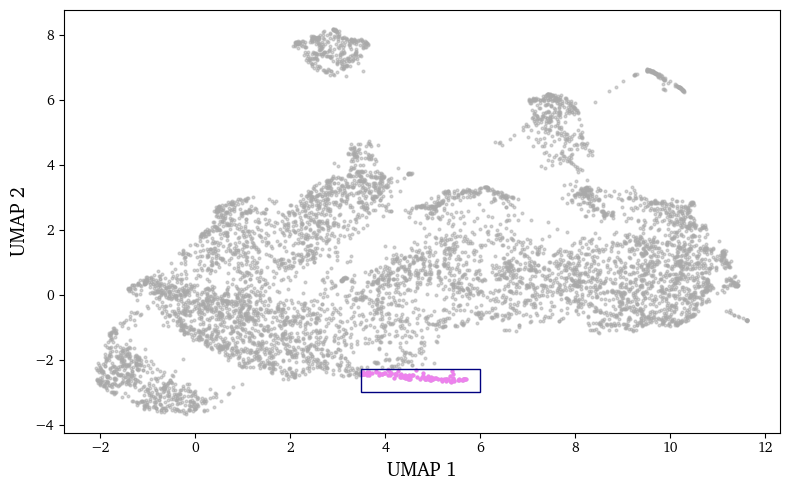

In [149]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(3.5, 6), umap_ylim=(-3, -2.3))

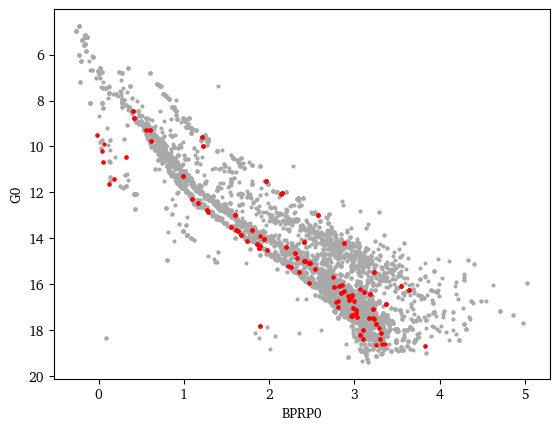

In [150]:
plot_cmd(mask_x, mask_y)

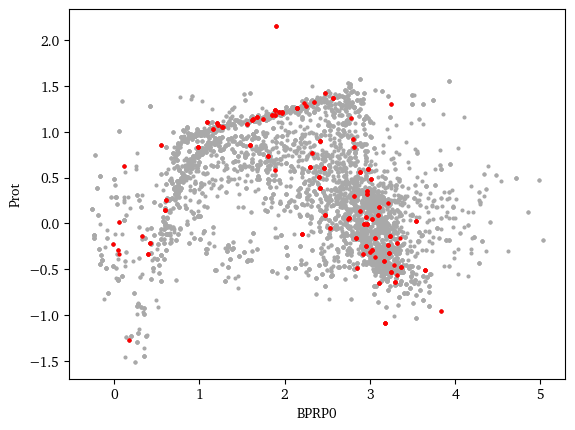

In [151]:
plot_prot(mask_x, mask_y)

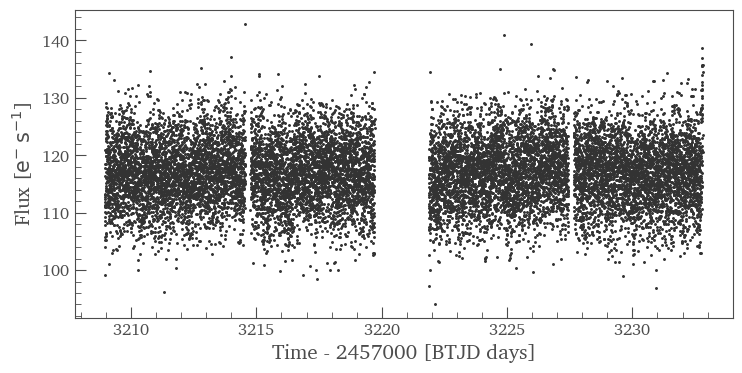

In [190]:
matching_indices = np.where(mask_x & mask_y)[0]
idx = np.random.choice(matching_indices)
tic = tic_ids[idx]
sector = sectors[idx]
res = lk.search_lightcurve(f"TIC {tic}", mission='TESS', author=['SPOC'],sector=sector,exptime=120)
lc = res[0].download()
lc.scatter(s=5,label='',marker='.')
plt.show()

## Binarity?

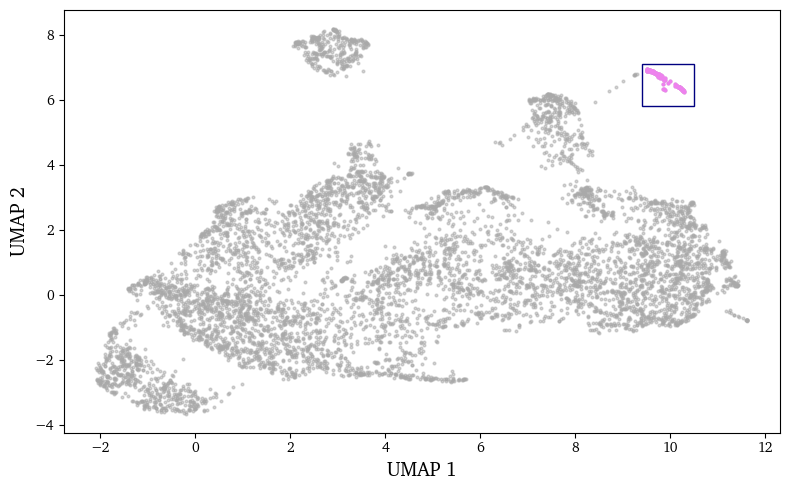

In [127]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(9.4, 10.5), umap_ylim=(5.8, 7.1))

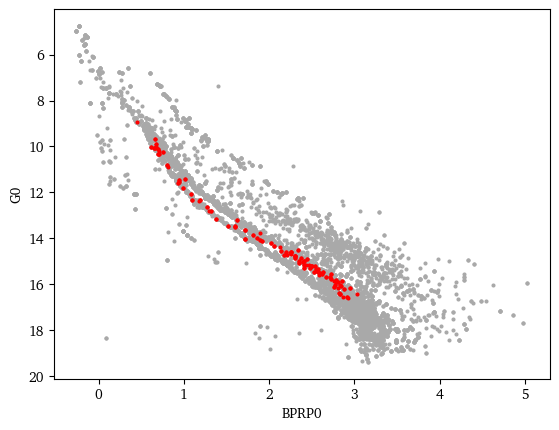

In [128]:
plot_cmd(mask_x, mask_y)

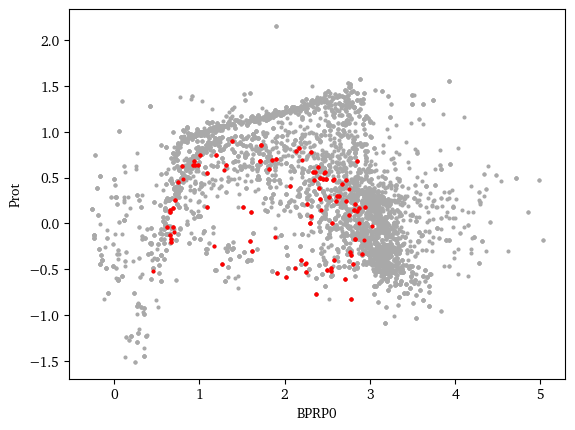

In [129]:
plot_prot(mask_x, mask_y)

### Pre-Main sequence

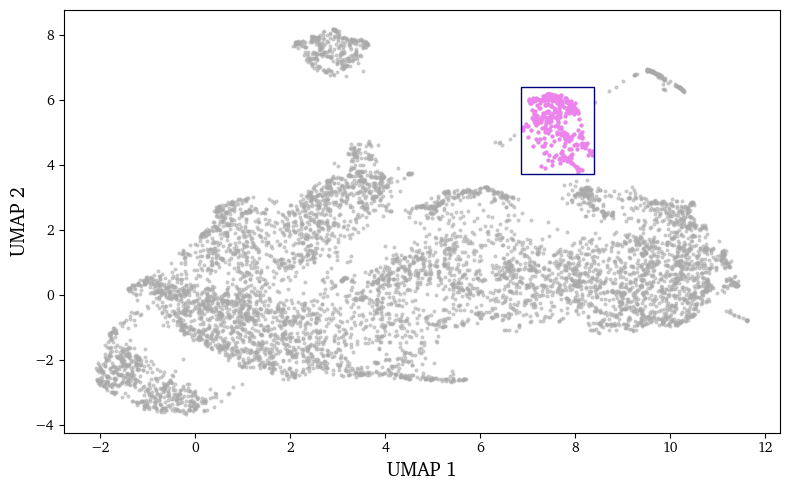

In [198]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(6.85, 8.4), umap_ylim=(3.7, 6.4))

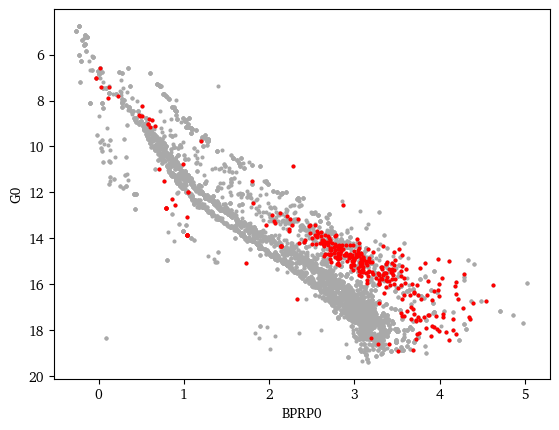

In [199]:
plot_cmd(mask_x, mask_y)

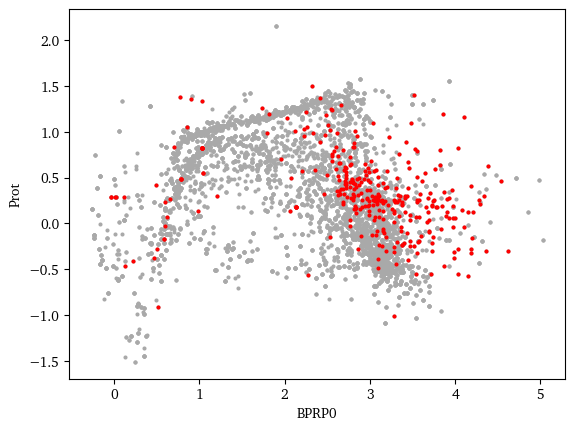

In [200]:
plot_prot(mask_x, mask_y)

## Something in light curve?

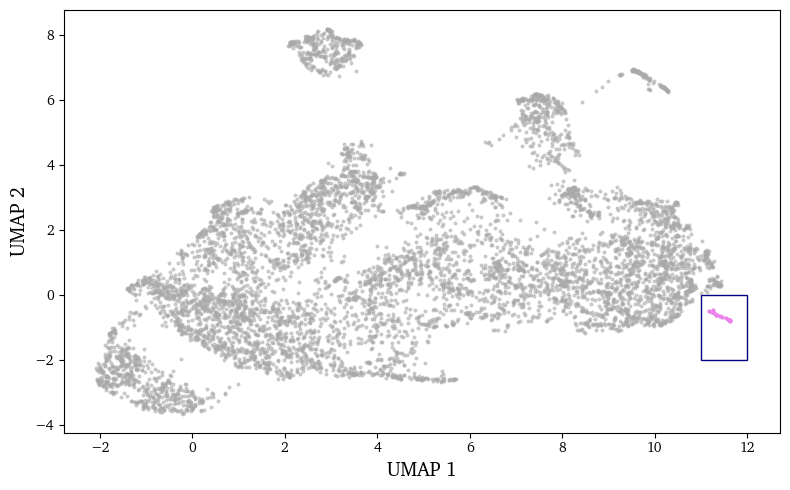

In [118]:
mask_x, mask_y = plot_umap_bounds(embedding, umap_xlim=(11, 12), umap_ylim=(-2, 0))

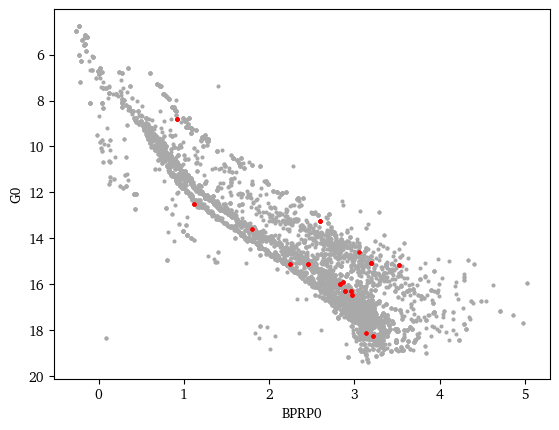

In [119]:
plot_cmd(mask_x, mask_y)

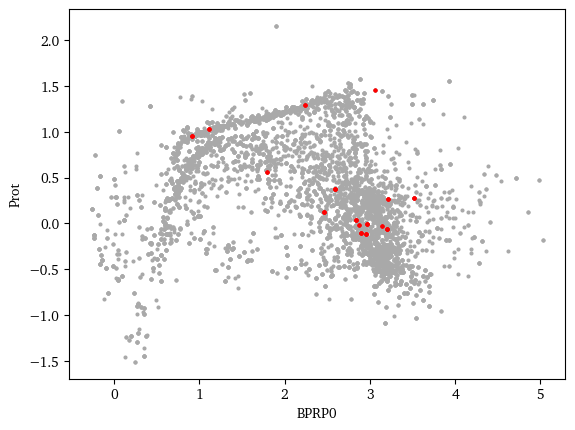

In [120]:
plot_prot(mask_x, mask_y)

### Inspect matching points

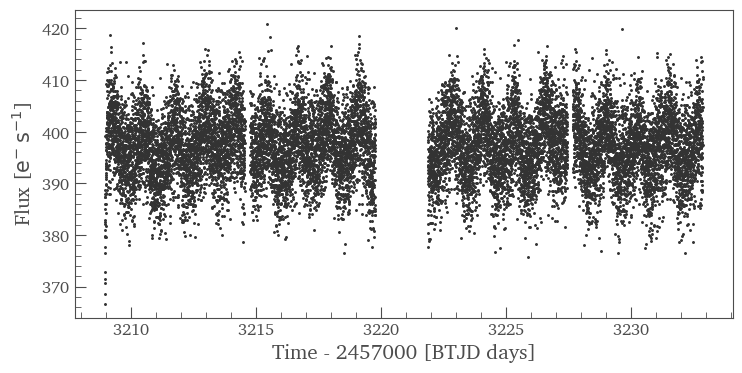

In [175]:
matching_indices = np.where(mask_x & mask_y)[0]
idx = np.random.choice(matching_indices)
tic = tic_ids[idx]
sector = sectors[idx]
res = lk.search_lightcurve(f"TIC {tic}", mission='TESS', author=['SPOC'],sector=sector,exptime=120)
lc = res[0].download()
lc.scatter(s=5,label='',marker='.')
plt.show()

## Look for high mass stars

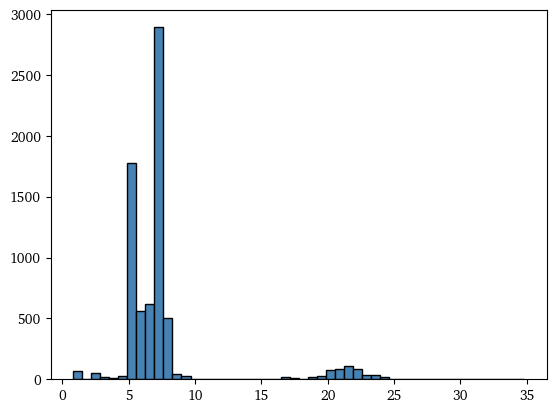

In [202]:
plt.hist(df['parallax'], bins=50, color='steelblue', edgecolor='black')
plt.show()

In [201]:
df

,GaiaDR3_ID,tic,num_refs,Prot,mem_prob_val,age_Myr,parallax,parallax_error,G0,G0_err,BP0,BP0_err,RP0,RP0_err,BPRP0,BPRP0_err
0,117709729140216320,405461319,2,6.484,0.929,112.2,6.559600,0.015855,11.681048,0.011626,12.110080,0.012618,11.086786,0.011007,1.023294,0.016744
1,117709729140216320,405461319,2,6.484,0.929,112.2,6.559600,0.015855,11.681048,0.011626,12.110080,0.012618,11.086786,0.011007,1.023294,0.016744
2,144171233106399104,456945485,1,9.164,1.000,775.0,21.744518,0.020119,8.404495,0.010005,8.769614,0.010044,7.868650,0.010019,0.900964,0.014187
3,144171233106399104,456945485,1,9.164,1.000,775.0,21.744518,0.020119,8.404495,0.010005,8.769614,0.010044,7.868650,0.010019,0.900964,0.014187
4,144171233106399104,456945485,1,9.164,1.000,775.0,21.744518,0.020119,8.404495,0.010005,8.769614,0.010044,7.868650,0.010019,0.900964,0.014187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7149,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592
7150,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592
7151,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592
7152,71371262561007232,353928999,2,0.766,0.950,112.2,7.200060,0.023453,9.455693,0.010919,9.693075,0.011486,9.053662,0.010544,0.639413,0.015592


In [203]:
hm_gids = df.loc[df['parallax'] > 15, 'GaiaDR3_ID'].values

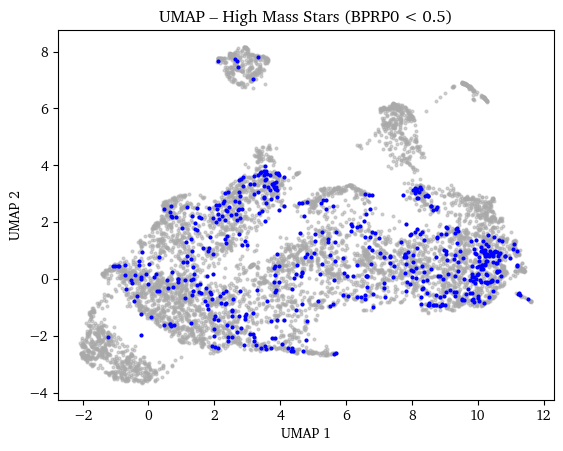

In [204]:
mask = [gid in hm_gids for gid in gaia_ids]
umap_hm = embedding[mask]
plt.scatter(embedding[:, 0], embedding[:, 1], color='darkgrey', s=15, alpha=0.5, marker='.')
plt.scatter(umap_hm[:, 0], umap_hm[:, 1], color='blue', s=15, alpha=1, marker='.')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP – High Mass Stars (BPRP0 < 0.5)')
plt.show()

# Composite UMAP with both regions

In [28]:
umap_xlim_fr = [9.4,10.5]
umap_ylim_fr = [5.8,7.1]

umap_xlim_pms=[6.85, 8.4]
umap_ylim_pms=[3.7, 6.4]


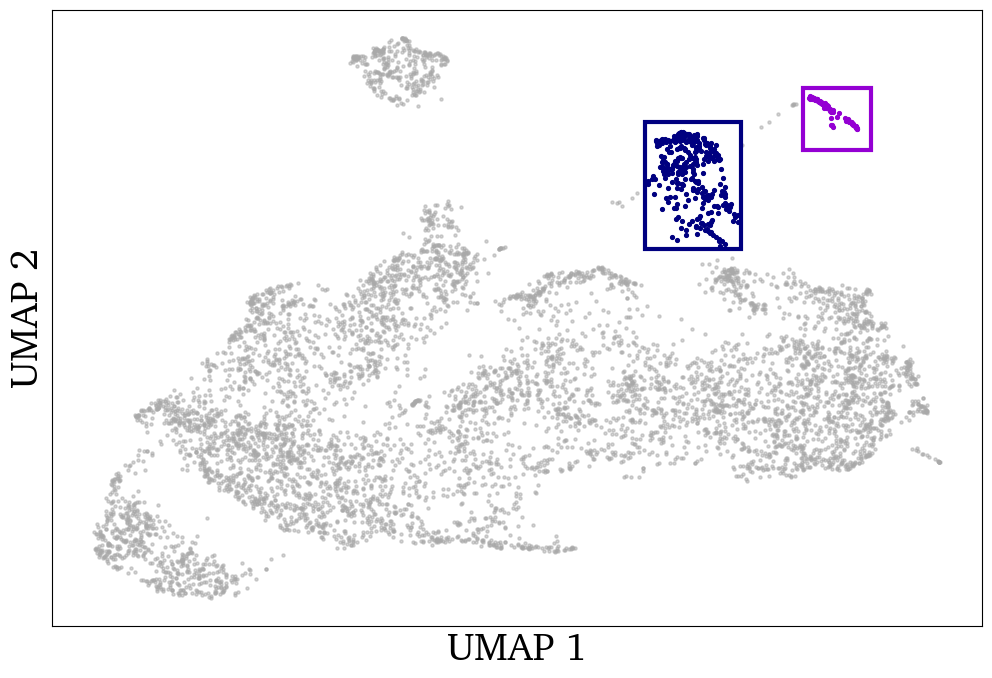

In [29]:
rect_fr = patches.Rectangle(
    (umap_xlim_fr[0], umap_ylim_fr[0]),        # (x0, y0) lower-left corner
    umap_xlim_fr[1] - umap_xlim_fr[0],       # width
    umap_ylim_fr[1] - umap_ylim_fr[0],       # height
    edgecolor='darkviolet',
    alpha=1,
    facecolor='none',
    linewidth=3
)

rec_pms = patches.Rectangle(
    (umap_xlim_pms[0], umap_ylim_pms[0]),        # (x0, y0) lower-left corner
    umap_xlim_pms[1] - umap_xlim_pms[0],       # width
    umap_ylim_pms[1] - umap_ylim_pms[0],       # height
    edgecolor='navy',
    alpha=1,
    facecolor='none',
    linewidth=3
)

mask_x_fr = (embedding[:, 0] < umap_xlim_fr[1]) & (embedding[:, 0] > umap_xlim_fr[0])
mask_y_fr = (embedding[:, 1] < umap_ylim_fr[1]) & (embedding[:, 1] > umap_ylim_fr[0])

mask_x_pms = (embedding[:, 0] < umap_xlim_pms[1]) & (embedding[:, 0] > umap_xlim_pms[0])
mask_y_pms = (embedding[:, 1] < umap_ylim_pms[1]) & (embedding[:, 1] > umap_ylim_pms[0])

x_all = embedding[:, 0]
y_all = embedding[:, 1]

x_p = embedding[mask_x_fr & mask_y_fr, 0]
y_p = embedding[mask_x_fr & mask_y_fr, 1]

x_pms = embedding[mask_x_pms & mask_y_pms, 0]
y_pms = embedding[mask_x_pms & mask_y_pms, 1]

fig, ax = plt.subplots(figsize=(12,8))
sc = ax.scatter(x_all,y_all, color='darkgrey', s=20, alpha=0.5, marker='.')
sc = ax.scatter(x_p, y_p, color='darkviolet', s=30, alpha=1, marker='.',label='fast rotators')
sc = ax.scatter(x_pms, y_pms, color='navy', s=30, alpha=1, marker='.',label='slow rotators')
ax.add_patch(rect_fr)
ax.add_patch(rec_pms)
plt.xlabel('UMAP 1',fontsize=28)
plt.ylabel('UMAP 2',fontsize=28)
ax.set_xticks([])
ax.set_yticks([])
# plt.legend()

plt.show()

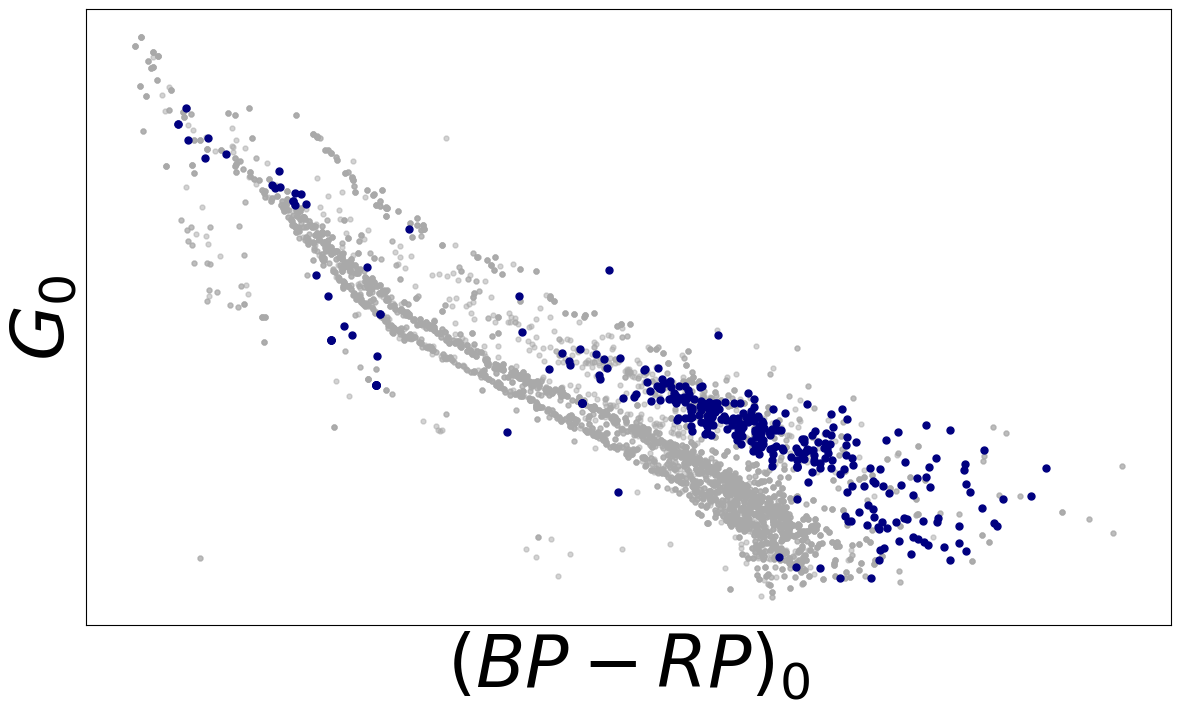

In [283]:
matching_indices_pms = np.where(mask_x_pms & mask_y_pms)
matching_gids = gaia_ids[matching_indices_pms]

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.figure(figsize=(14, 8))
plt.scatter(df['BPRP0'],df['G0'], s=50, alpha=0.5,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],df_region['G0'], s=100, alpha=1,c='navy',marker='.')
plt.gca().invert_yaxis()
plt.xlabel(r'$(BP-RP)_0$',fontsize=52)
plt.ylabel(r'$G_0$',fontsize=52)
plt.xticks([],fontsize=10)
plt.yticks([],fontsize=10)
plt.show()

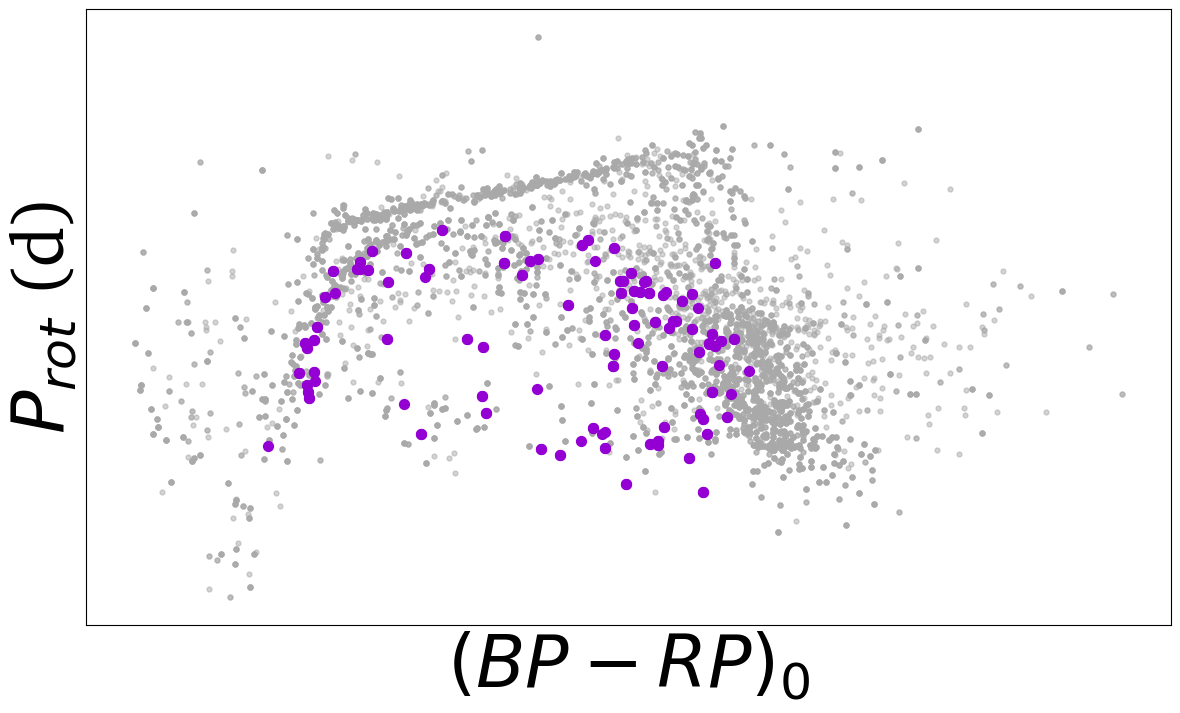

In [287]:
matching_indices_fr = np.where(mask_x_fr & mask_y_fr)
matching_gids = gaia_ids[matching_indices_fr]

# Filter stars
df_region = df[df.loc[:, 'GaiaDR3_ID'].isin(matching_gids)]
plt.figure(figsize=(14, 8))
plt.scatter(df['BPRP0'],np.log10(df['Prot']), s=50, alpha=0.5,c='darkgray',marker='.')
plt.scatter(df_region['BPRP0'],np.log10(df_region['Prot']), s=200, alpha=1,c='darkviolet',marker='.')
plt.xlabel(r'$(BP-RP)_0$',fontsize=52)
plt.ylabel(r'$P_{rot}$ (d)',fontsize=52)
plt.xticks([],fontsize=10)
plt.yticks([],fontsize=10)
plt.show()

# Comparison of exoplanet hosts

In [37]:
FINAL_DATA_FILE = '../../final_model/parallel_fixed/e110/umap/umap_age_best_model_multiscale_data.npz'

final_data      = np.load(FINAL_DATA_FILE, allow_pickle=True)
final_embedding = final_data['embedding']    # (N, 2)
final_ages      = final_data['ages']         # (N,) Myr
final_bprp0     = final_data['bprp0']        # (N,)
final_gaia_ids  = final_data['gaia_ids']     # (N,) str
final_tic_ids   = final_data['tic_ids']      # (N,) int64
final_sectors = final_data['sectors']        # (N,) int64

print(f'Loaded {len(final_ages)} samples')
print(f'Embedding shape: {final_embedding.shape}')
print(f'Age range:   {final_ages.min():.1f} – {final_ages.max():.1f} Myr')
print(f'BPRP0 range: {final_bprp0.min():.2f} – {final_bprp0.max():.2f}')

Loaded 60631 samples
Embedding shape: (60631, 2)
Age range:   nan – nan Myr
BPRP0 range: nan – nan


In [38]:
x_all = embedding[:, 0]
y_all = embedding[:, 1]

In [39]:
host_gids = pd.read_csv('../../final_pretrain/host_all_metadata.csv')['GaiaDR3_ID'].astype(str).values

In [40]:
host_gids

<ArrowStringArray>
['4828528063821835648', '4650314511916109696',  '602348482997667840',
 '4762582895440787712', '3578638842054261248', '4919770108539385472',
 '3997075206232885888', '4021079911593673600', '2439890557725244800',
 '2129492824571882240',
 ...
 '5287961677550103424', '2105000687666286592', '2076186611079704320',
 '1620024491110370688', '1385293808145621504', '2106306082845810048',
 '2104257967562692096', '2106290208647252608', '2099583977992504576',
 '2100214788429438336']
Length: 3952, dtype: str

In [41]:
final_gaia_ids

array(['4931155036049677312', '4931155036049677312',
       '4931155036049677312', ..., '2303332931542914048',
       '2303332931542914048', '2303332931542914048'],
      shape=(60631,), dtype='<U22')

In [42]:
len(final_embedding)

60631

In [43]:
len(umap_host)

19977

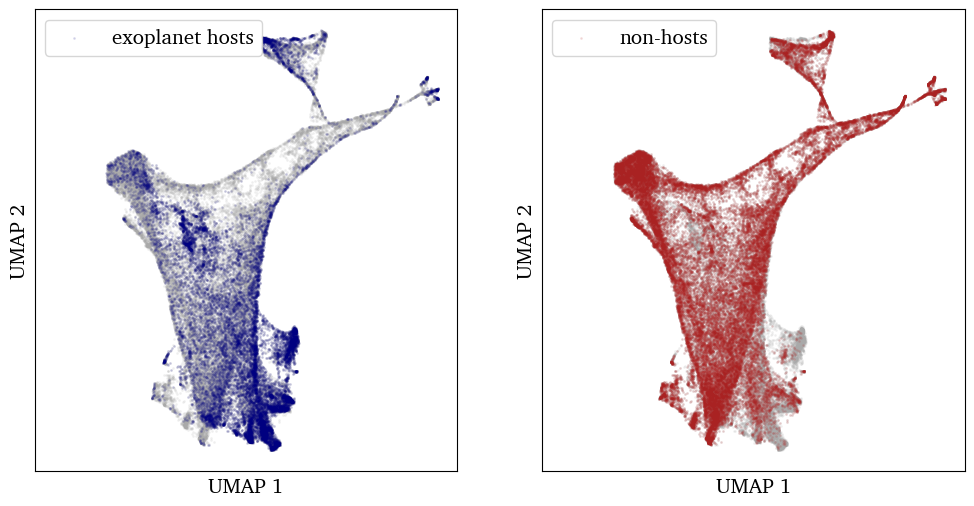

In [51]:
hgids_umap = [gid in host_gids for gid in final_gaia_ids]
nonh_gids_umap = [gid not in host_gids for gid in final_gaia_ids]
umap_nonhost = final_embedding[nonh_gids_umap]
umap_host = final_embedding[hgids_umap]

plt.subplots(1,2, figsize=(12, 6))

plt.subplot(1,2,1)
plt.scatter(final_embedding[:, 0], final_embedding[:, 1], color='darkgrey', s=5, alpha=0.1, marker='.')
plt.scatter(umap_host[:, 0], umap_host[:, 1], color='navy', s=5, alpha=0.1, marker='.',label='exoplanet hosts')
plt.xlabel('UMAP 1',fontsize=15)
plt.ylabel('UMAP 2',fontsize=15)
plt.xticks([],[])
plt.yticks([],[])
plt.xlim(-3,20)
plt.legend(fontsize=15)

plt.subplot(1,2,2)
plt.scatter(final_embedding[:, 0], final_embedding[:, 1], color='darkgrey', s=5, alpha=0.1, marker='.')
plt.scatter(umap_nonhost[:, 0], umap_nonhost[:, 1], color='firebrick', s=5, alpha=0.1, marker='.',label='non-hosts')
plt.xlabel('UMAP 1',fontsize=15)
plt.ylabel('UMAP 2',fontsize=15)
plt.xticks([],[])
plt.yticks([],[])
plt.xlim(-3,20)
plt.legend(fontsize=15)



plt.show()